In [2]:
import keypoint_moseq as kpms
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
import yaml
import re

CONF_CALIBRATION = True # If KPMS will combine data from 2 seperate models
RES_CALIBRATION = True # If different datasets are used with different resolutions, thus different mouse size per pixel

In [1]:
import torch; print(torch.cuda.is_available()); print(torch.cuda.get_device_name(0))

ModuleNotFoundError: No module named 'torch'

"/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/"

# Prepare unified RI dataset:
- Calibrate the KPMS algorithm to learn the relationship between keypoint errors and confidence scores. This is done on the original data temporal resolution
- Downsampling videos to a common temporal resolution (10 FPS)
- Do keypoint interpolation on datasets that do not have frame rates multiples of 10 (e.g., 15 and 27 FPS)

There are different datasets with different FPS: 10, 15, 27, 30 and 50

### Setup project

In [13]:
dlc_config_file = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06\config.yaml"
#dlc_config_file = r"/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06/config.yaml"

kpmoseq_dir = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset_topView_KPMS_Resident_calibrated"
#kpmoseq_dir = r"/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident"

kpms.setup_project(kpmoseq_dir, deeplabcut_config=dlc_config_file, overwrite = False)

config = lambda: kpms.load_config(kpmoseq_dir)

The directory `C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\t
rainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset
_topView_KPMS_Resident_calibrated` already exists. Use
`overwrite=True` or pick a different name


### Use the last video of each mouse to calibrate KPMS (original frame rate)

Note that the trainingSessions dataset was initially analyzed using a multianimal model. For this reason the files were first converted to signle animal format using the Resident's keypoints.

The script used was: **__C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\neuroPixels_aggressionTraining\convert_multiAnimal2singleAnimal_tracking_DLC.ipynb__**

In [4]:
datasets = [
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\analyzedVideos_trainingSessions_DLC_singleAnimal"),
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\analyzedVideos_maladapivePreScreening_DLC_singleAnimal"),
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\analyzedVideos_Stefanos_RIdataset_DLC_singleAnimal"),
]

all_h5 = [f for d in datasets for f in d.rglob("*.h5") if "_filtered" not in f.stem]

last = {}
for f in all_h5:
    mouse = f.stem.split("_Day")[0]
    day = int(re.search(r"_Day(\d+)", f.stem).group(1))
    if mouse not in last or day > last[mouse][0]:
        last[mouse] = (day, f)

noise_calibration_files = [str(v[1]) for v in last.values()]

In [5]:
from collections import defaultdict

mouse_datasets = defaultdict(set)
for f in all_h5:
    mouse_datasets[f.stem.split("_Day")[0]].add(next(d for d in datasets if f.is_relative_to(d)))

last = {}
for f in all_h5:
    mouse = f.stem.split("_Day")[0]
    if len(mouse_datasets[mouse]) > 1:      # skip mice found in more than one dataset
        continue
    day = int(re.search(r"_Day(\d+)", f.stem).group(1))
    if mouse not in last or day > last[mouse][0]:
        last[mouse] = (day, f)

noise_calibration_files = [str(v[1]) for v in last.values()]

In [6]:
# For some reason, bodyparts returned from kpms.load_keypoints is of type "set", not "list". This means that bodypart label's order is not aligned anymore with the other variables 

with open(dlc_config_file, "r") as f:
        dlcConfig = yaml.safe_load(f)

bodyparts = dlcConfig["bodyparts"]

In [9]:
coordinates, confidences, bodyparts = kpms.load_keypoints(noise_calibration_files, "deeplabcut")

Loading keypoints:   0%|                        | 0/141 [00:00<?, ?it/s]

Loading keypoints: 100%|██████████████| 141/141 [00:01<00:00, 85.98it/s]


#### Remaping the confidences between the multi animal model onto the single animal model from the unified dataset

In [10]:
import re, numpy as np

# ---- fitted confidence-remap parameters (from the shared-frame GT calibration) ----
# maps trainingSessions confidence (model A) onto the unifiedDataset scale (model B):
#   c' = 10 ** ((sA*log10(c) + iA - iB) / sB)
sA, iA = -0.92, -1.23      # trainingSessions (model A):  log10(conf) -> log10(err)
sB, iB = -0.88, -1.65      # unifiedDataset  (model B)
EPS = 1e-3

Agg = ["975826","975827","975833","978772","978774","988590","997838","1010820","1010823","1010826","1029741"]
nonAgg = ["975830","978775","1010819","997839","997840","997841","1029736","1029739","1032216"]
maladaptive = ["978513","978527","978528","1010832","1013590","1034805","1034814"]
remap_ids = set(Agg + nonAgg + maladaptive)


def remap_confidence(c):
    """Map model-A (trainingSessions) confidence onto the model-B (unifiedDataset) scale."""
    c = np.clip(np.asarray(c, float), EPS, 1.0)
    return np.clip(10.0 ** ((sA * np.log10(c) + iA - iB) / sB), 0.0, 1.0)


def needs_remap(name):
    """True only for trainingSessions sessions: mouse ID in the arrays AND a
    2-digit DayNN (e.g. Day02). Day002 (3-digit) is unifiedDataset -> left as-is."""
    mid = re.search(r"mouse(\d+)", name)
    day = re.search(r"_Day(\d+)", name)
    return bool(mid and mid.group(1) in remap_ids and day and len(day.group(1)) == 2)

remapped = []
for name in confidences:
    if needs_remap(name):
        confidences[name] = remap_confidence(confidences[name])
        remapped.append(name)

print(f"remapped {len(remapped)}/{len(confidences)} recordings")
for n in remapped:
    print("  ", n)

remapped 25/141 recordings
   mouse1010819_Day12_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk
   mouse1010820_Day12_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk
   mouse1010823_Day12_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk
   mouse1010826_Day12_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk
   mouse1010832_Day19_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk
   mouse1013590_Day19_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk
   mouse1029736_Day12_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk
   mouse1029739_Day12_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shu

In [14]:
kpms.update_config(kpmoseq_dir, outlier_scale_factor=6.0)

coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    kpmoseq_dir,
    overwrite=False,
    **config()
)

In [15]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

### Populate the video_dir (DLC) with the videos whose sessions are going to be used to calibration

In [17]:
import shutil

video_source_roots = [       # wherever the ORIGINAL videos actually live
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\RI_datasets\trainingSessions"),
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\RI_datasets\maladapivePreScreening"),
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\RI_datasets\Stefanos_RIdataset"),
]

calib_video_dir = Path(kpmoseq_dir) / "calibration_videos"
calib_video_dir.mkdir(exist_ok=True)

exts = ("*.avi", "*.mp4")
index = {p.stem: p for root in video_source_roots for e in exts for p in root.rglob(e)}

missing = []
for key in coordinates:
    stem = key.split("DLC")[0]               # 'mouse1034811_Day005' or 'mouse..._topView_comp'
    if stem in index:
        shutil.copy2(index[stem], calib_video_dir / index[stem].name)
    else:
        missing.append(stem)

print("missing:", missing)

kpms.update_config(kpmoseq_dir, video_dir=str(calib_video_dir))

np.save(Path(calib_video_dir) /"calibration_files.npy", noise_calibration_files)

missing: []


In [19]:
import keypoint_moseq.calibration as _cal

# keep a stable reference to the real function (re-run safe)
if not hasattr(_cal, "_orig_sample_error_frames"):
    _cal._orig_sample_error_frames = _cal.sample_error_frames

def _sample_more(confidences, bodyparts, use_bodyparts,
                 num_bins=10, num_samples=200, conf_pseudocount=1e-3):
    return _cal._orig_sample_error_frames(
        confidences, bodyparts, use_bodyparts,
        num_bins=num_bins, num_samples=num_samples, conf_pseudocount=conf_pseudocount)

_cal.sample_error_frames = _sample_more

Loading sample frames: 100%|██████████| 200/200 [00:04<00:00, 41.73it/s]


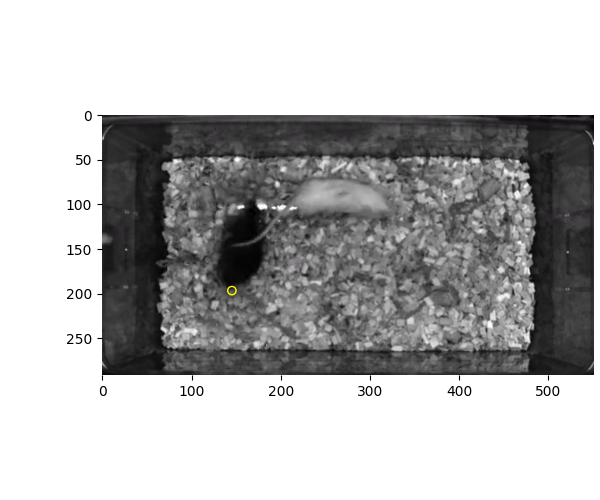

In [21]:
%matplotlib widget
kpms.noise_calibration(kpmoseq_dir, coordinates, confidences, overwrite = False, **config())

## Load data for training (same as for calibration)

In [4]:
from pathlib import PureWindowsPath

calib_video_dir = Path(kpmoseq_dir) / "calibration_videos"
calibration_files = np.load(Path(calib_video_dir) /"calibration_files.npy")

h5Dataset = Path("/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/analyzedVideos_unifiedDataset_DLC_singleAnimal_downsampled_10fps")

linuxPaths = []
for h5_path in calibration_files:
    path_str = h5_path
    fileName = PureWindowsPath(path_str).name

    h5 = next(h5Dataset.rglob(fileName))

    linuxPaths.append(str(h5))


In [5]:
kpms.update_config(kpmoseq_dir, fps = 10)

In [6]:
coordinates, confidences, bodyparts = kpms.load_keypoints(linuxPaths, "deeplabcut")

Loading keypoints:   0%|                        | 0/141 [00:00<?, ?it/s]

Loading keypoints: 100%|██████████████| 141/141 [00:04<00:00, 33.12it/s]


In [7]:
kpms.update_config(kpmoseq_dir, outlier_scale_factor=6.0)

coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    kpmoseq_dir,
    overwrite=False,
    **config()
)

In [8]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

## Extracting the number of components from videography data that explain >= 90% of the variance in behavioral syllables

>=90.0% of variance exlained by 5 components.


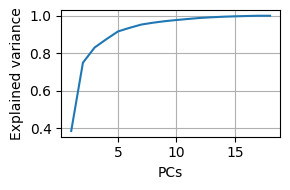

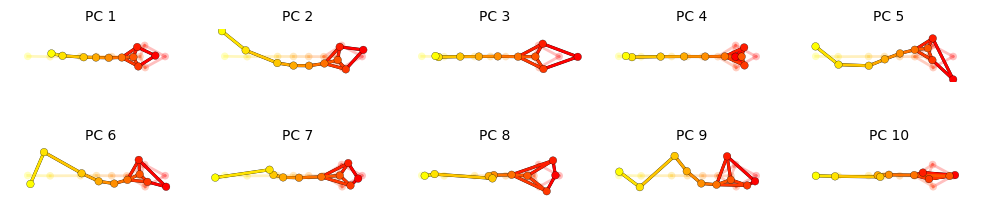

In [22]:
plt.close("all")
pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, kpmoseq_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=kpmoseq_dir)
kpms.plot_pcs(pca, project_dir=kpmoseq_dir, **config())

In [23]:
kpms.update_config(kpmoseq_dir, latent_dim=5) # >= 90.0% of the variance is explained by 6 components

In [24]:
kpms.update_config(
    kpmoseq_dir,
    sigmasq_loc=kpms.estimate_sigmasq_loc(data["Y"], data["mask"], filter_size=config()["fps"])
)

## **Kappa scan**: Hyperparameter that that determines the rate of transitions between syllables. Higher values of kappa lead to longer syllables and smaller values lead to shorter syllables.

In [9]:
from jax_moseq.utils import set_mixed_map_iters

set_mixed_map_iters(6)

Fitting model with kappa=100.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-100.0


 49%|█████████████████▏                 | 25/51 [00:54<00:49,  1.91s/it]

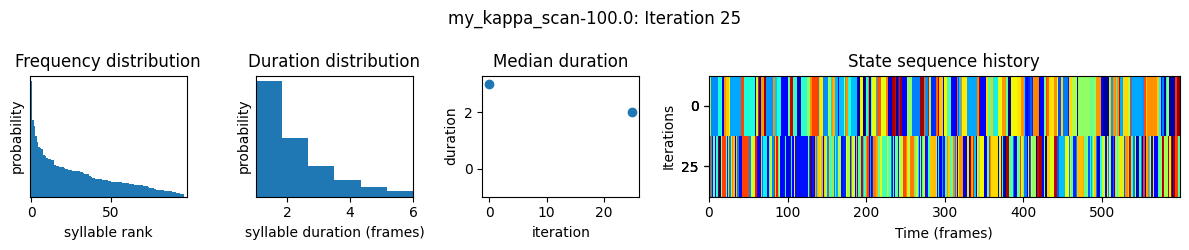

 98%|██████████████████████████████████▎| 50/51 [01:45<00:01,  1.96s/it]

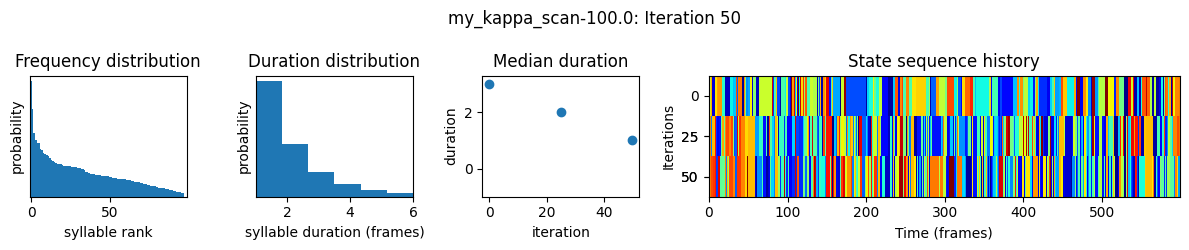

100%|███████████████████████████████████| 51/51 [01:48<00:00,  2.13s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-100.0


 17%|█████▋                            | 25/151 [02:17<08:16,  3.94s/it]

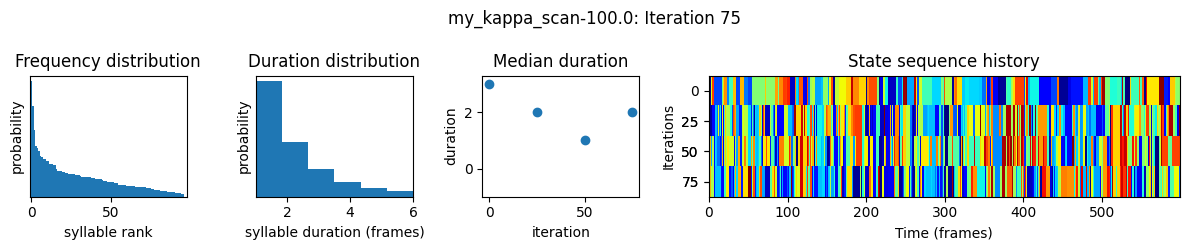

 33%|███████████▎                      | 50/151 [03:57<06:35,  3.92s/it]

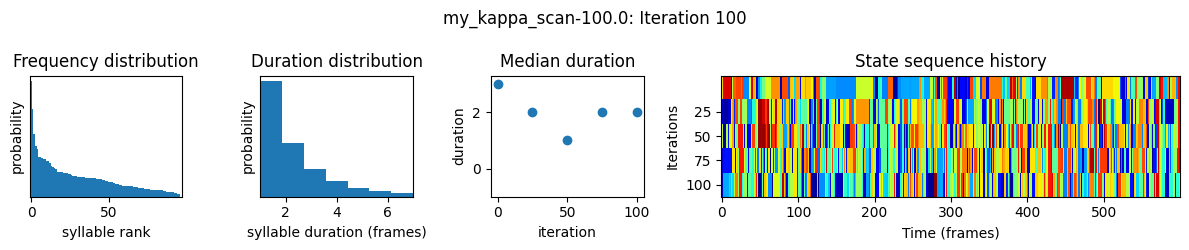

 50%|████████████████▉                 | 75/151 [05:36<04:57,  3.92s/it]

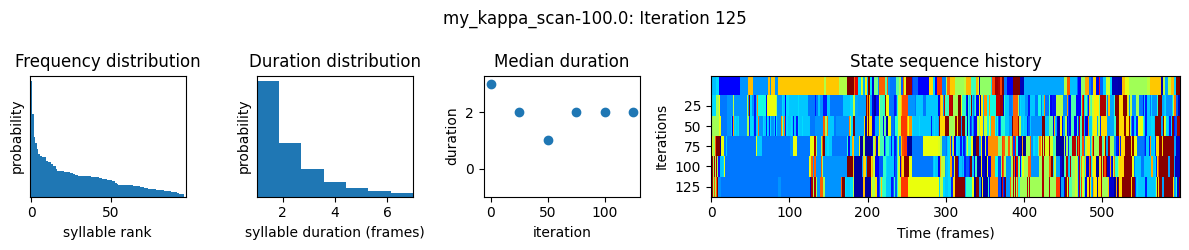

 66%|█████████████████████▊           | 100/151 [07:16<03:19,  3.91s/it]

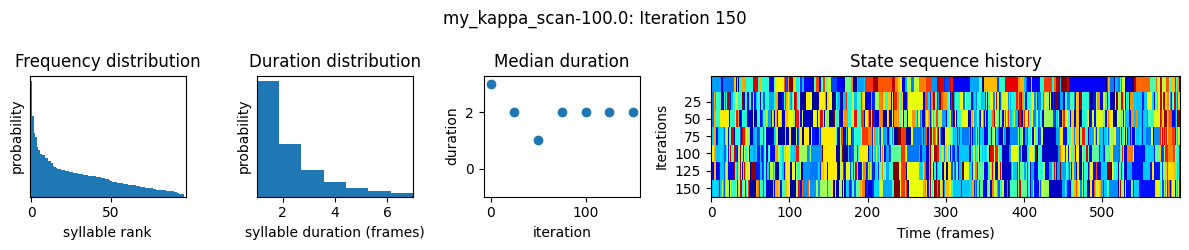

 83%|███████████████████████████▎     | 125/151 [08:56<01:41,  3.91s/it]

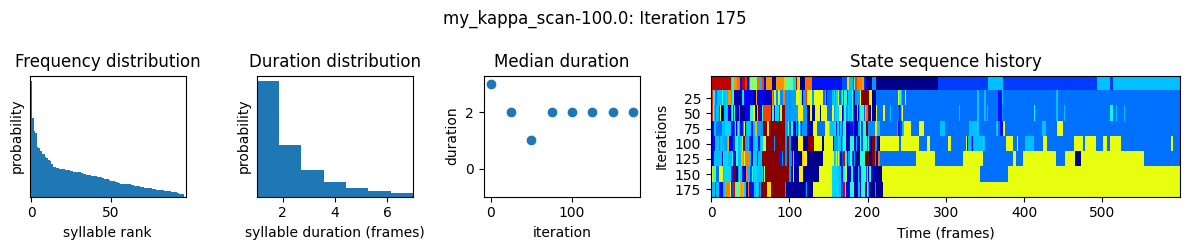

 99%|████████████████████████████████▊| 150/151 [10:35<00:03,  3.91s/it]

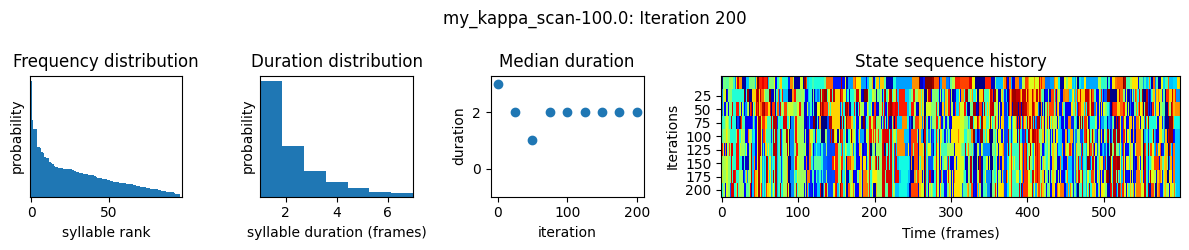

100%|█████████████████████████████████| 151/151 [10:41<00:00,  4.25s/it]


Fitting model with kappa=1000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-1000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.89s/it]

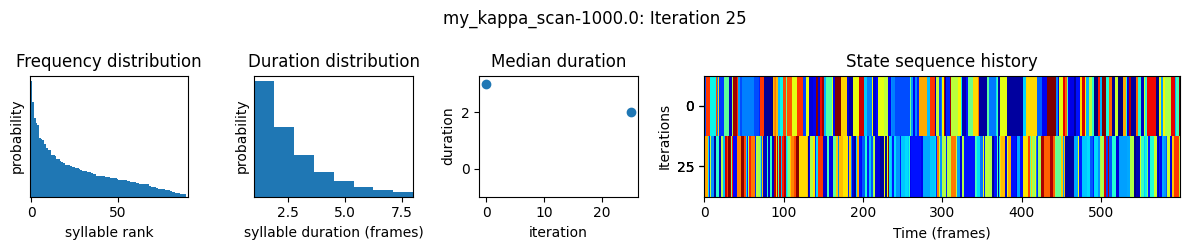

 98%|██████████████████████████████████▎| 50/51 [01:36<00:01,  1.89s/it]

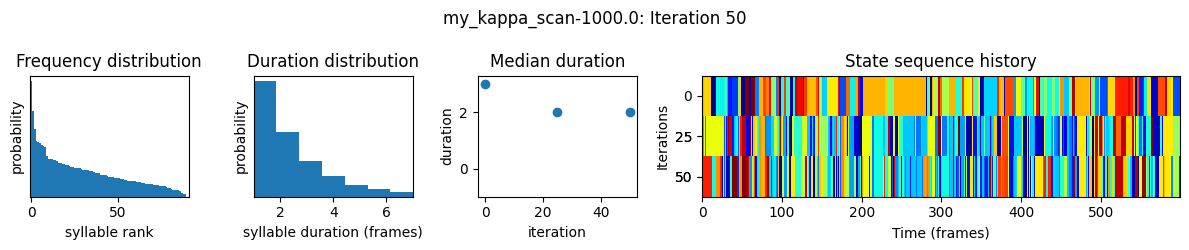

100%|███████████████████████████████████| 51/51 [01:39<00:00,  1.95s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-1000.0


 17%|█████▋                            | 25/151 [01:37<08:12,  3.91s/it]

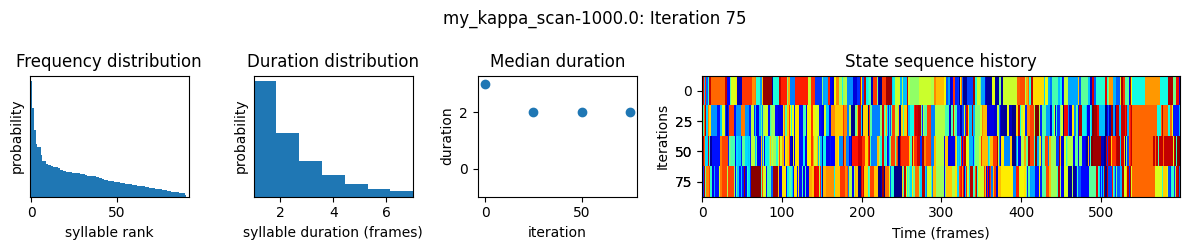

 33%|███████████▎                      | 50/151 [03:16<06:34,  3.91s/it]

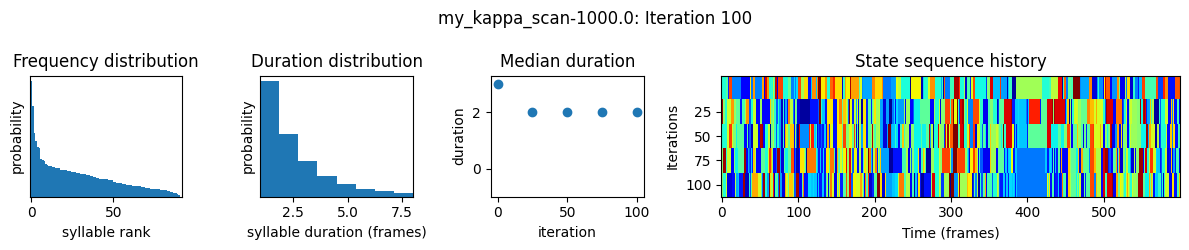

 50%|████████████████▉                 | 75/151 [04:56<04:57,  3.91s/it]

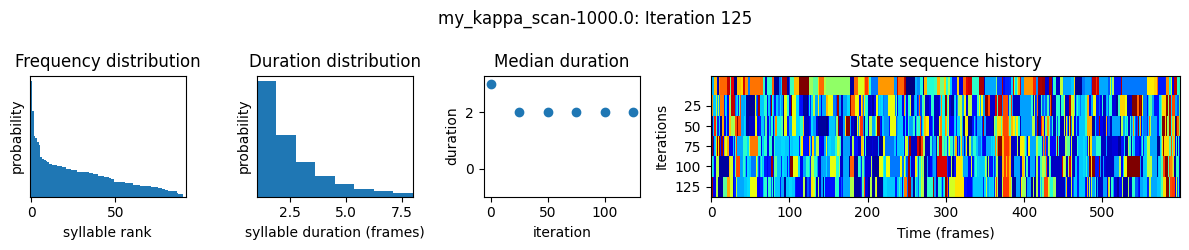

 66%|█████████████████████▊           | 100/151 [06:36<03:19,  3.90s/it]

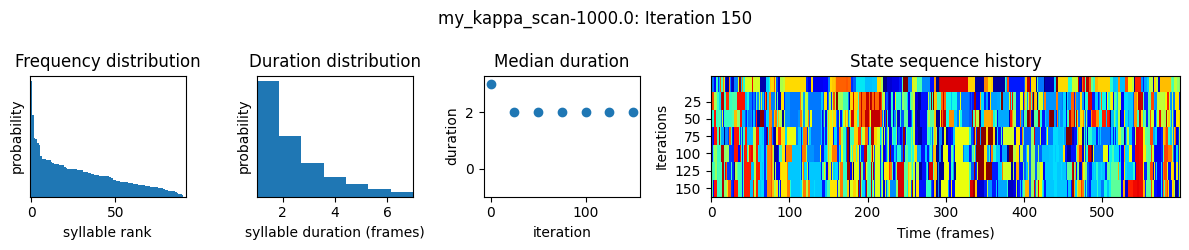

 83%|███████████████████████████▎     | 125/151 [08:16<01:42,  3.94s/it]

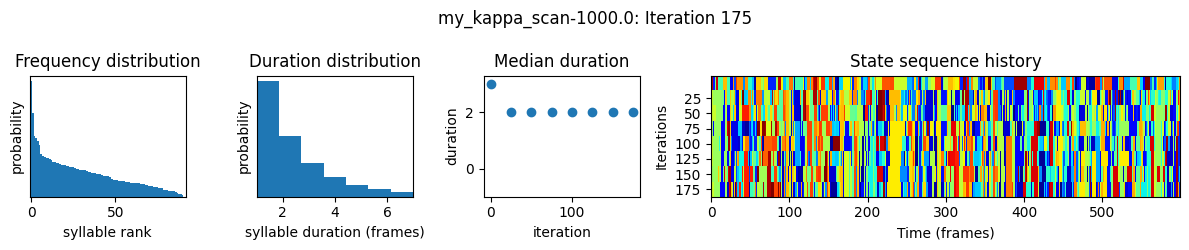

 99%|████████████████████████████████▊| 150/151 [09:56<00:03,  3.91s/it]

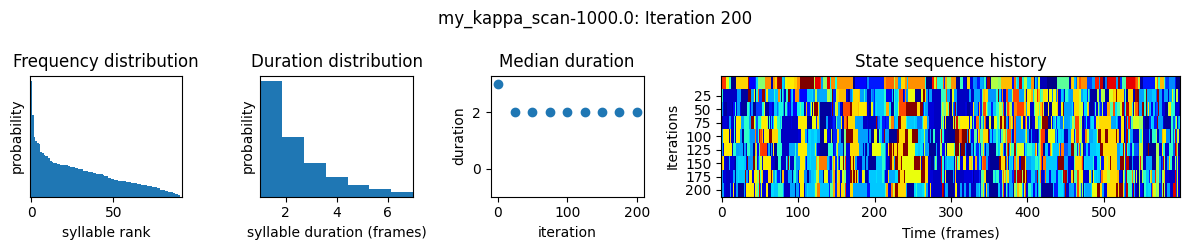

100%|█████████████████████████████████| 151/151 [10:02<00:00,  3.99s/it]


Fitting model with kappa=10000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-10000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.90s/it]

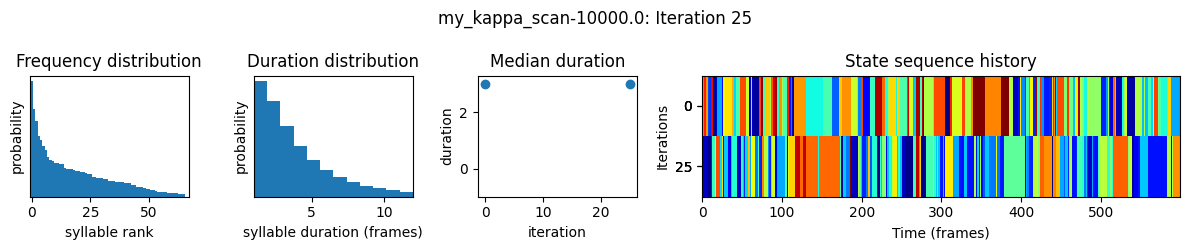

 98%|██████████████████████████████████▎| 50/51 [01:36<00:01,  1.90s/it]

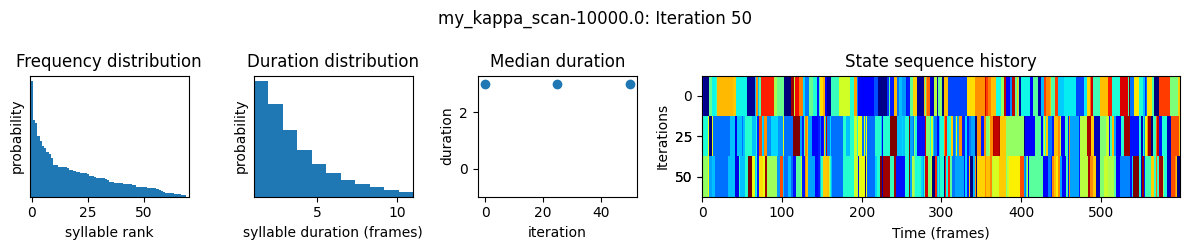

100%|███████████████████████████████████| 51/51 [01:40<00:00,  1.96s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-10000.0


 17%|█████▋                            | 25/151 [01:37<08:13,  3.91s/it]

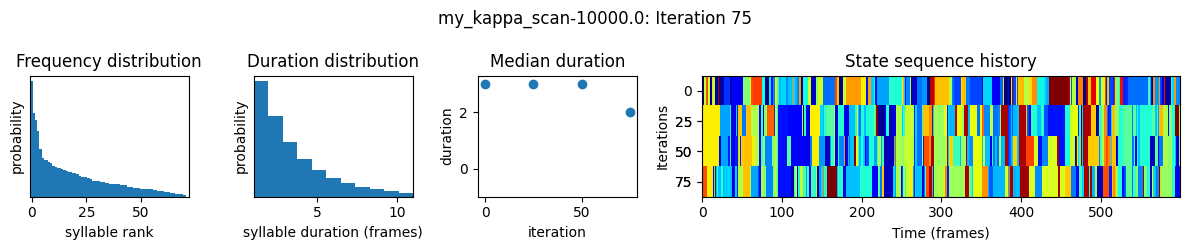

 33%|███████████▎                      | 50/151 [03:17<06:35,  3.91s/it]

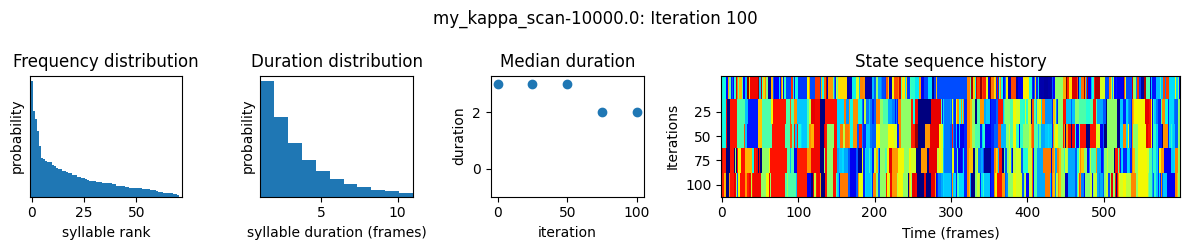

 50%|████████████████▉                 | 75/151 [04:56<04:57,  3.91s/it]

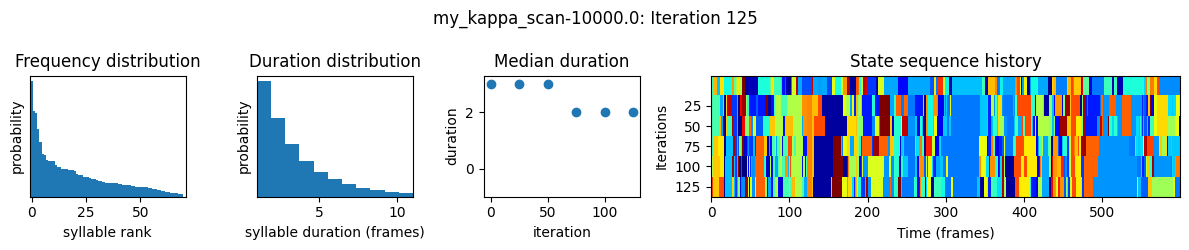

 66%|█████████████████████▊           | 100/151 [06:36<03:19,  3.91s/it]

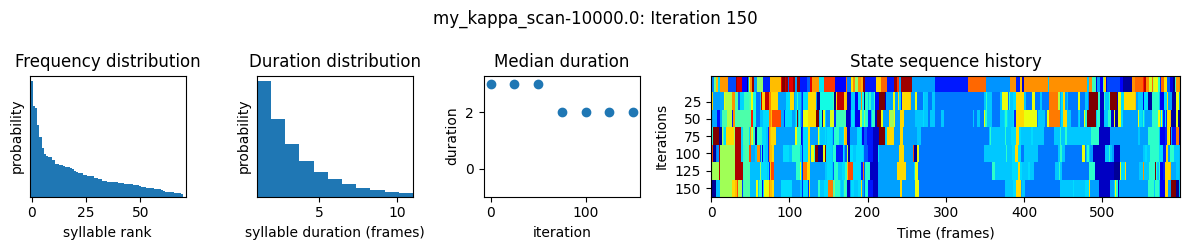

 83%|███████████████████████████▎     | 125/151 [08:15<01:41,  3.91s/it]

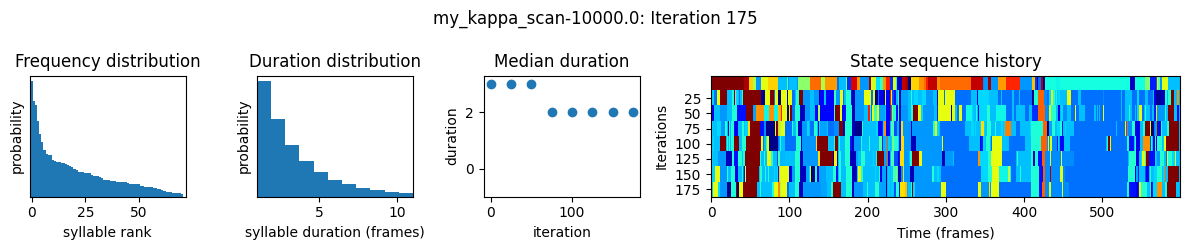

 99%|████████████████████████████████▊| 150/151 [09:55<00:03,  3.92s/it]

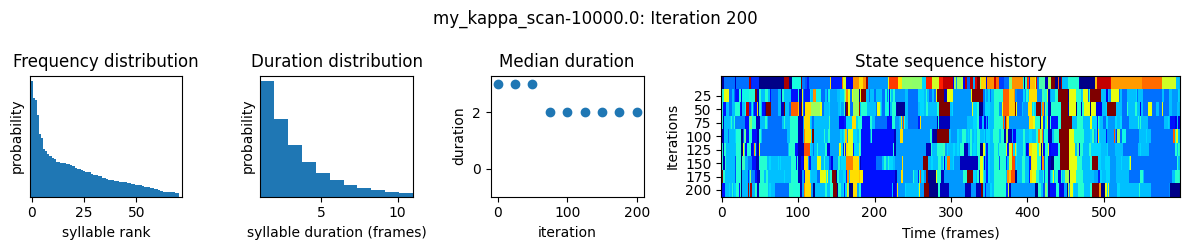

100%|█████████████████████████████████| 151/151 [10:01<00:00,  3.98s/it]


Fitting model with kappa=100000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-100000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.89s/it]

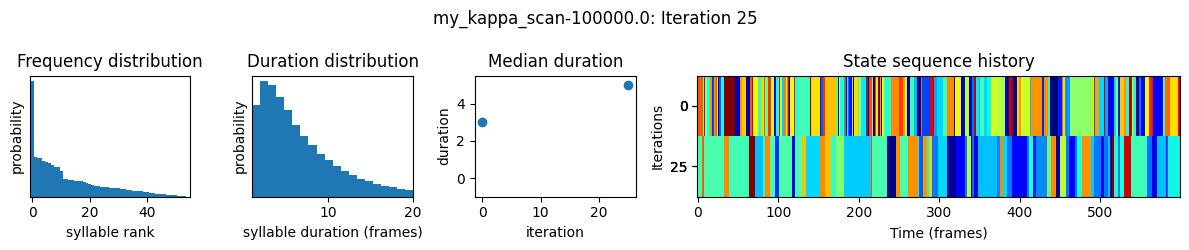

 98%|██████████████████████████████████▎| 50/51 [01:36<00:01,  1.90s/it]

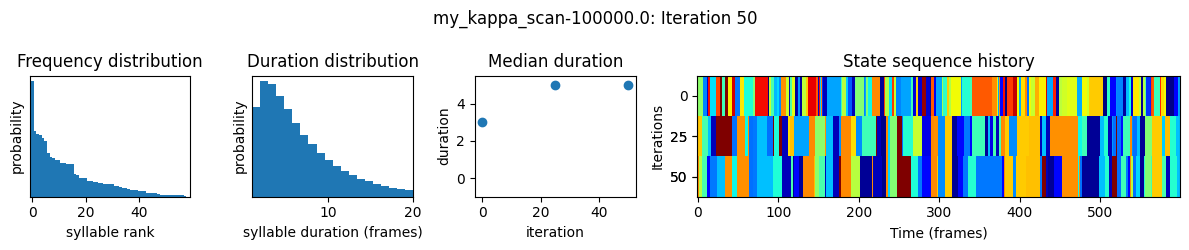

100%|███████████████████████████████████| 51/51 [01:39<00:00,  1.96s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-100000.0


 17%|█████▋                            | 25/151 [01:37<08:12,  3.91s/it]

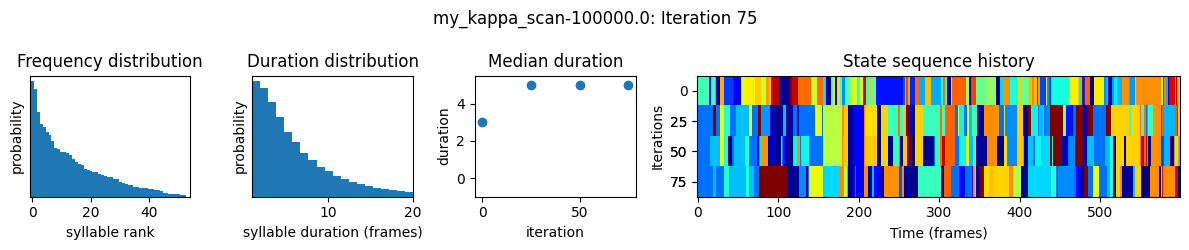

 33%|███████████▎                      | 50/151 [03:16<06:34,  3.90s/it]

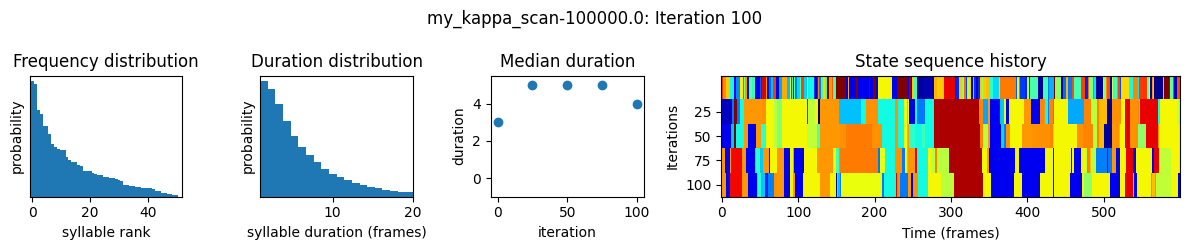

 50%|████████████████▉                 | 75/151 [04:56<04:56,  3.91s/it]

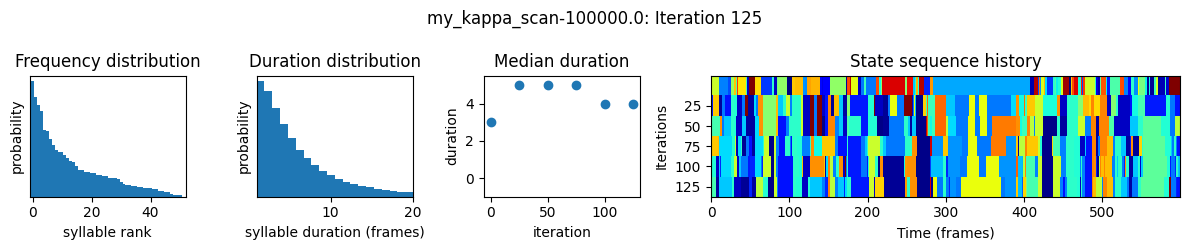

 66%|█████████████████████▊           | 100/151 [06:35<03:19,  3.91s/it]

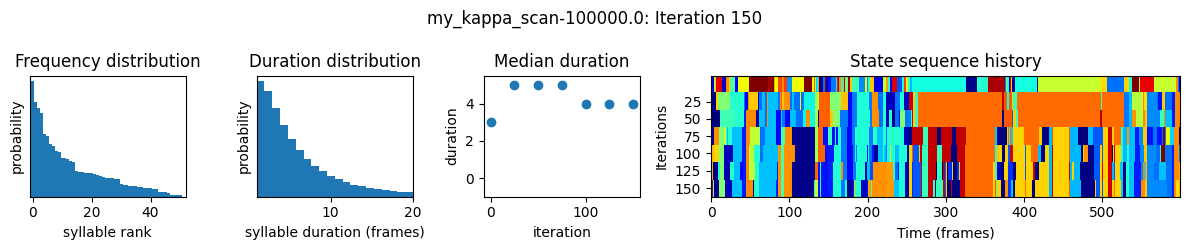

 83%|███████████████████████████▎     | 125/151 [08:15<01:42,  3.93s/it]

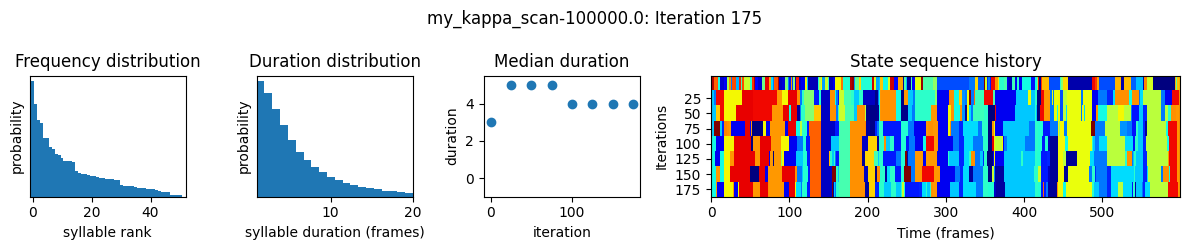

 99%|████████████████████████████████▊| 150/151 [09:55<00:03,  3.91s/it]

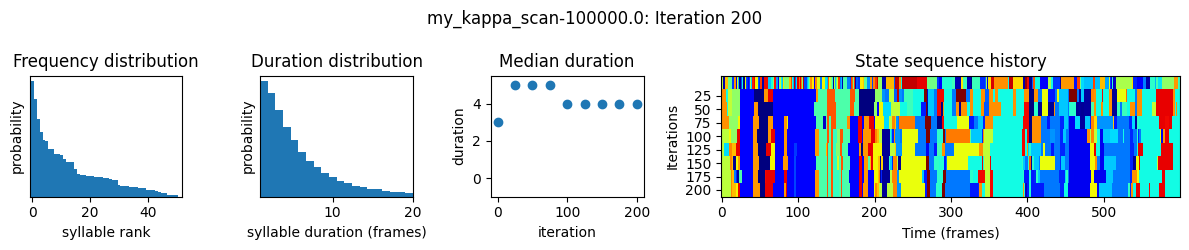

100%|█████████████████████████████████| 151/151 [10:01<00:00,  3.98s/it]


Fitting model with kappa=1000000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-1000000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.90s/it]

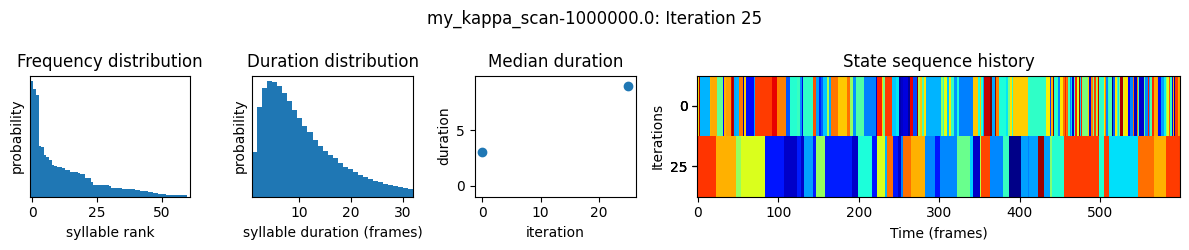

 98%|██████████████████████████████████▎| 50/51 [01:36<00:01,  1.90s/it]

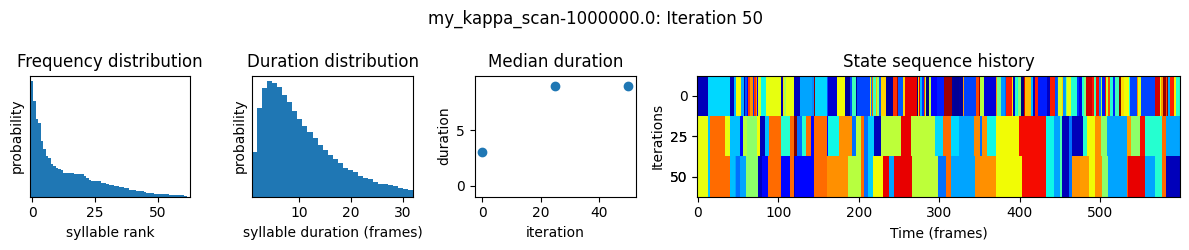

100%|███████████████████████████████████| 51/51 [01:39<00:00,  1.96s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-1000000.0


 17%|█████▋                            | 25/151 [01:37<08:14,  3.93s/it]

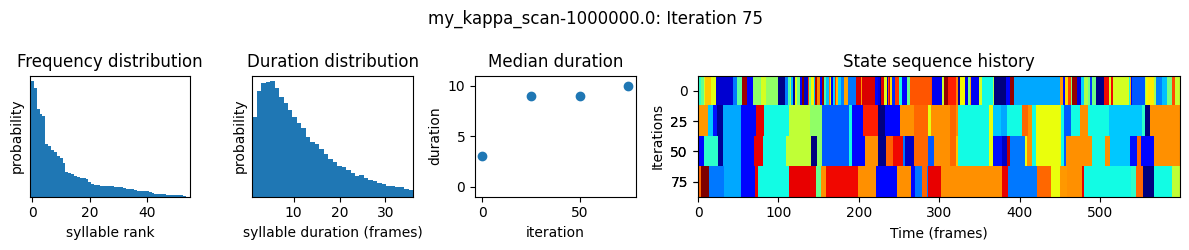

 33%|███████████▎                      | 50/151 [03:17<06:34,  3.91s/it]

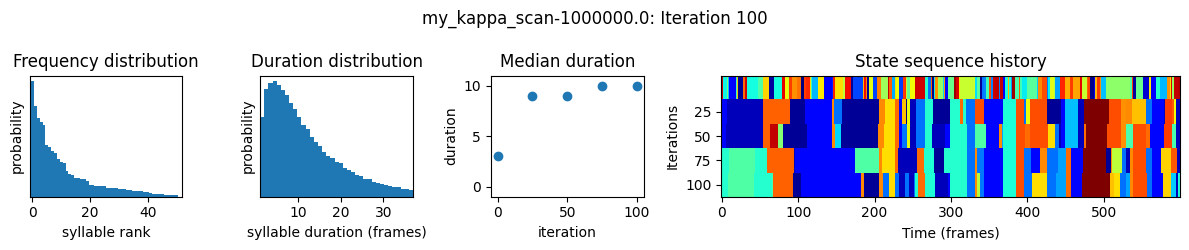

 50%|████████████████▉                 | 75/151 [04:56<04:57,  3.91s/it]

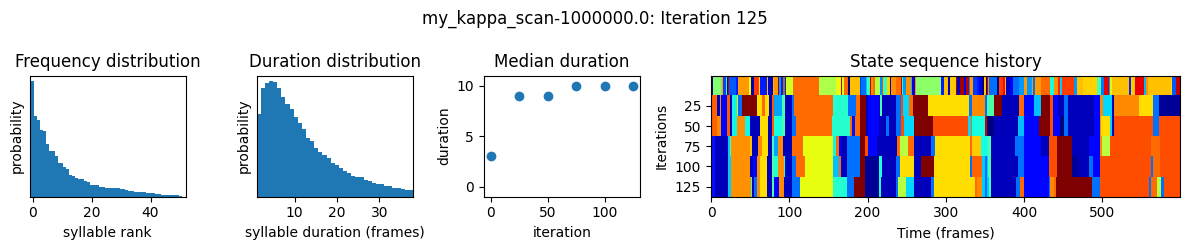

 66%|█████████████████████▊           | 100/151 [06:36<03:19,  3.91s/it]

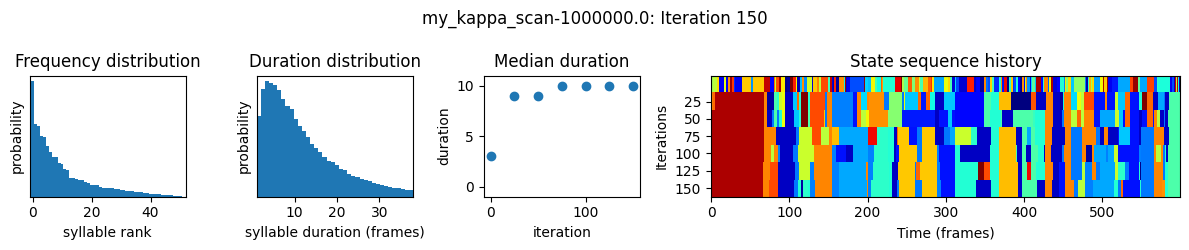

 83%|███████████████████████████▎     | 125/151 [08:15<01:41,  3.91s/it]

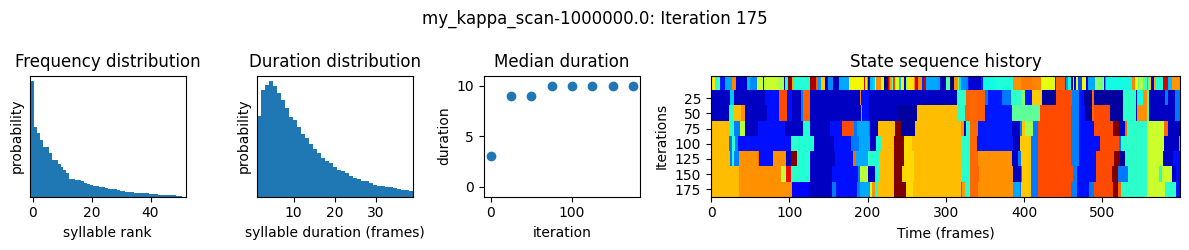

 99%|████████████████████████████████▊| 150/151 [09:55<00:03,  3.91s/it]

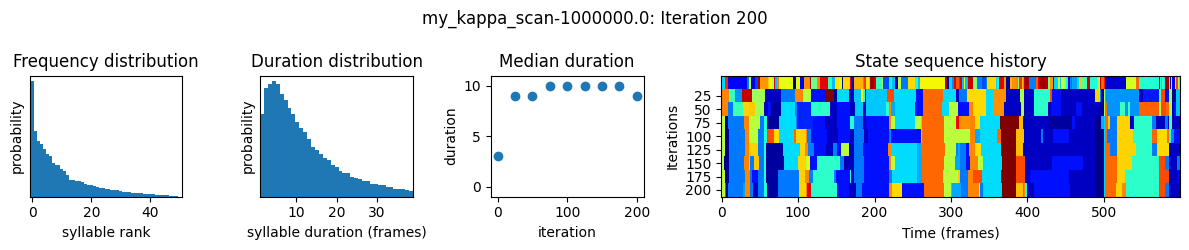

100%|█████████████████████████████████| 151/151 [10:01<00:00,  3.98s/it]


Fitting model with kappa=10000000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-10000000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.91s/it]

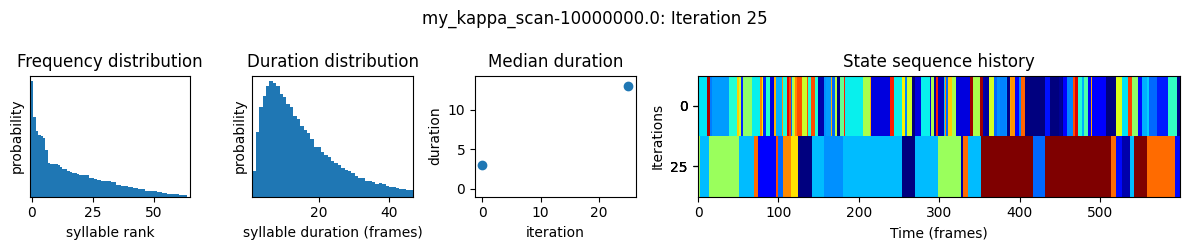

 98%|██████████████████████████████████▎| 50/51 [01:36<00:01,  1.91s/it]

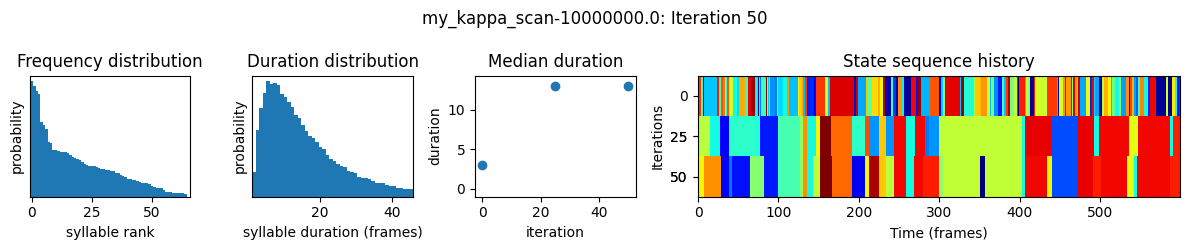

100%|███████████████████████████████████| 51/51 [01:40<00:00,  1.97s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-10000000.0


 17%|█████▋                            | 25/151 [01:37<08:13,  3.91s/it]

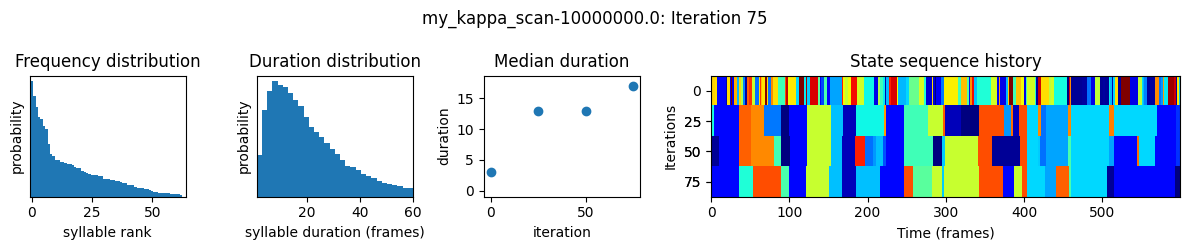

 33%|███████████▎                      | 50/151 [03:18<06:40,  3.97s/it]

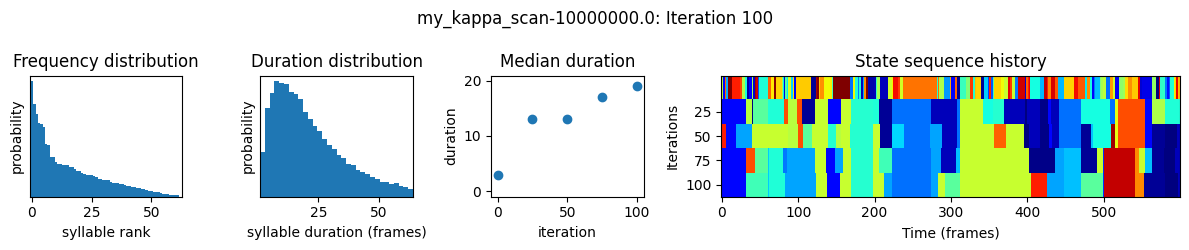

 50%|████████████████▉                 | 75/151 [04:59<05:01,  3.96s/it]

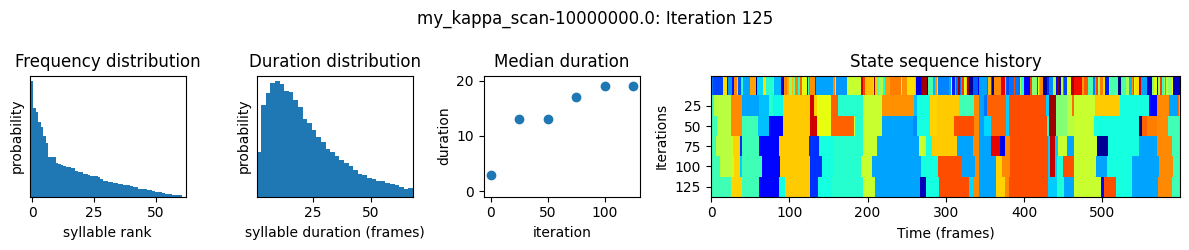

 66%|█████████████████████▊           | 100/151 [06:39<03:22,  3.96s/it]

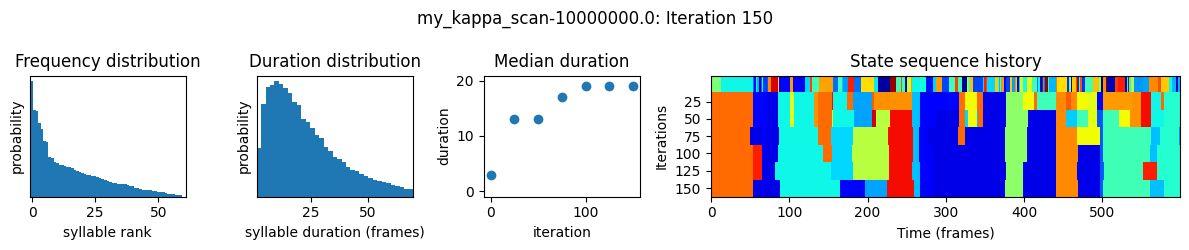

 83%|███████████████████████████▎     | 125/151 [08:21<01:43,  3.98s/it]

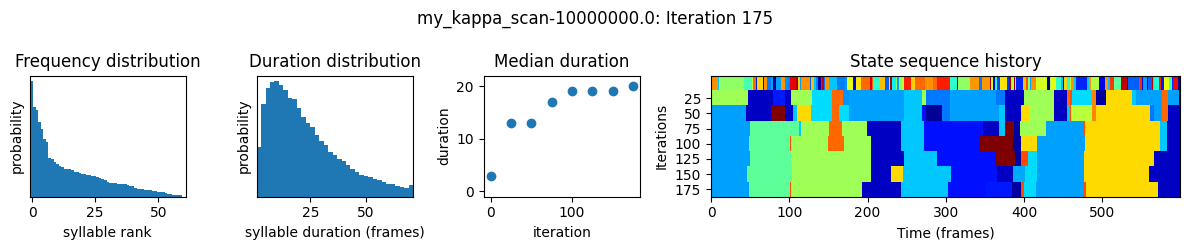

 99%|████████████████████████████████▊| 150/151 [10:02<00:03,  3.98s/it]

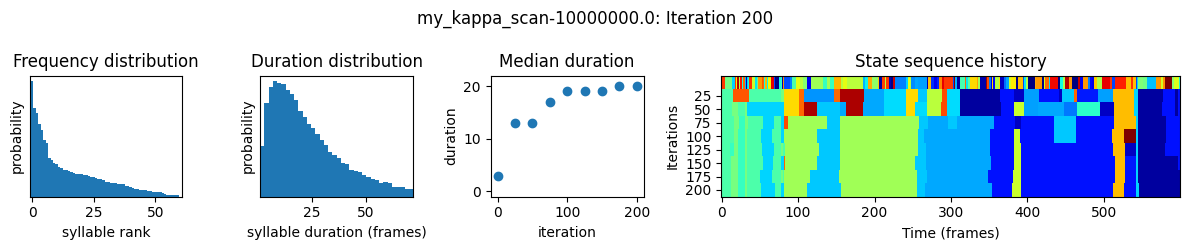

100%|█████████████████████████████████| 151/151 [10:09<00:00,  4.03s/it]


Fitting model with kappa=100000000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-100000000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.92s/it]

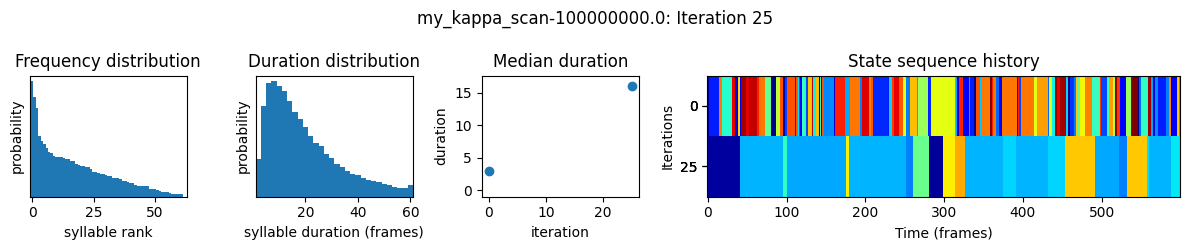

 98%|██████████████████████████████████▎| 50/51 [01:37<00:01,  1.91s/it]

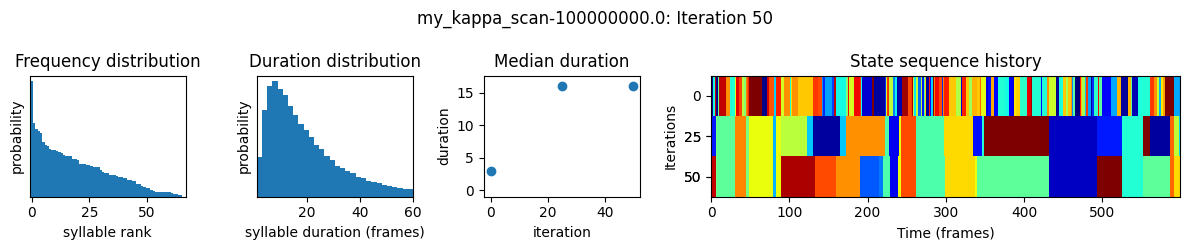

100%|███████████████████████████████████| 51/51 [01:40<00:00,  1.98s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-100000000.0


 17%|█████▋                            | 25/151 [01:37<08:13,  3.92s/it]

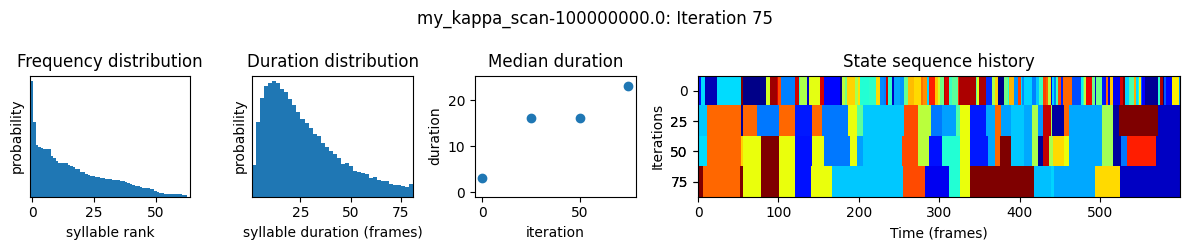

 33%|███████████▎                      | 50/151 [03:17<06:35,  3.92s/it]

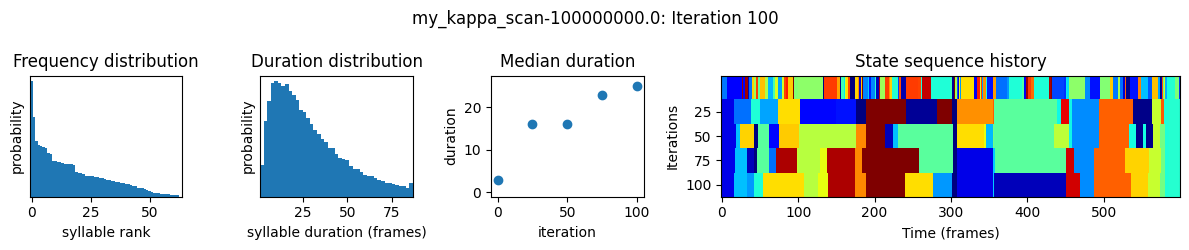

 50%|████████████████▉                 | 75/151 [04:57<05:01,  3.97s/it]

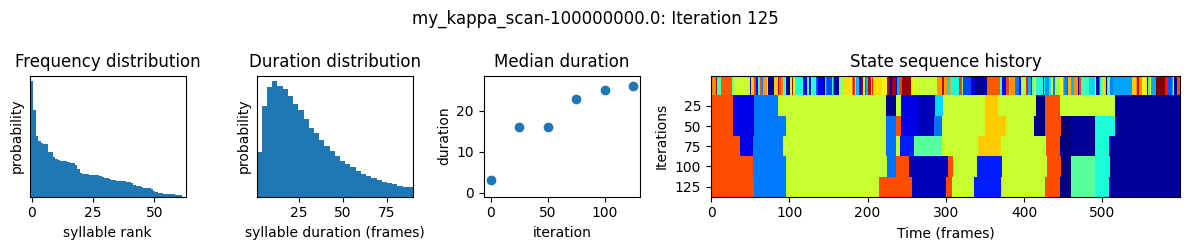

 66%|█████████████████████▊           | 100/151 [06:38<03:22,  3.97s/it]

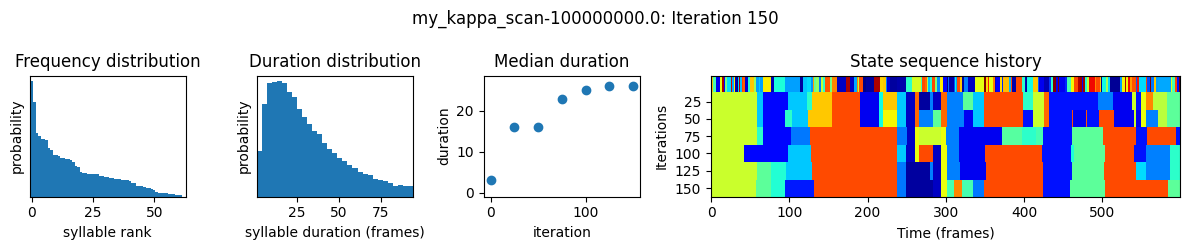

 83%|███████████████████████████▎     | 125/151 [08:19<01:43,  3.97s/it]

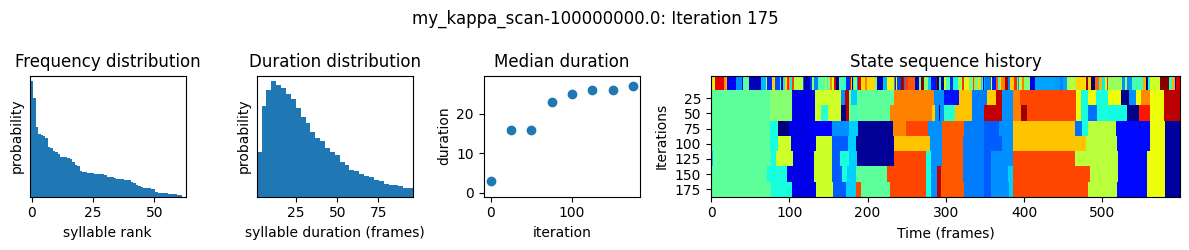

 99%|████████████████████████████████▊| 150/151 [10:00<00:03,  3.97s/it]

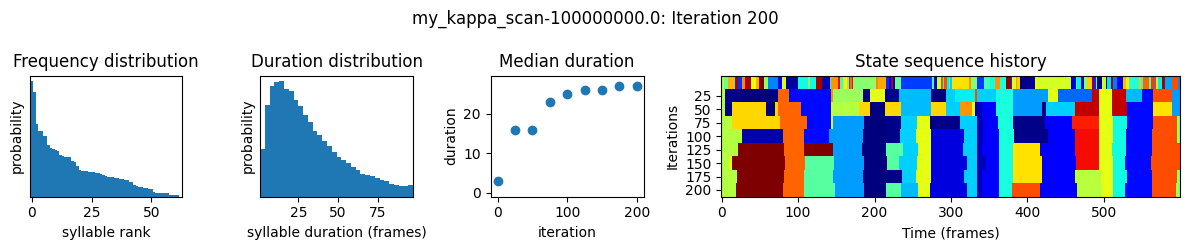

100%|█████████████████████████████████| 151/151 [10:06<00:00,  4.02s/it]


Fitting model with kappa=1000000000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-1000000000.0


 49%|█████████████████▏                 | 25/51 [00:48<00:50,  1.95s/it]

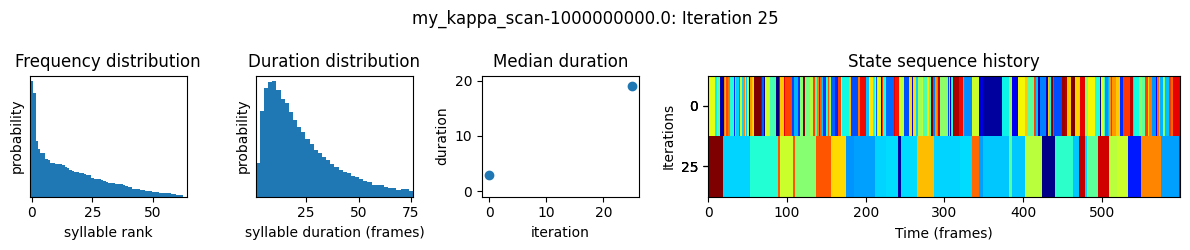

 98%|██████████████████████████████████▎| 50/51 [01:39<00:01,  1.95s/it]

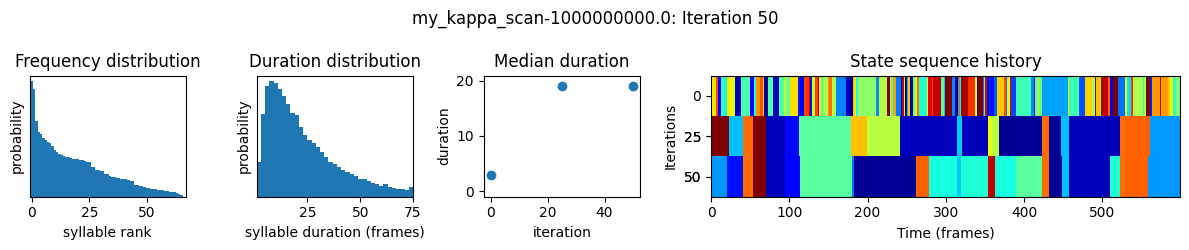

100%|███████████████████████████████████| 51/51 [01:42<00:00,  2.01s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-1000000000.0


 17%|█████▋                            | 25/151 [01:37<08:12,  3.91s/it]

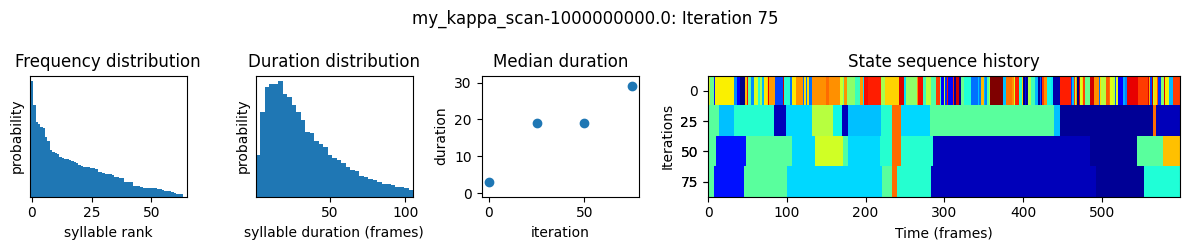

 33%|███████████▎                      | 50/151 [03:17<06:34,  3.91s/it]

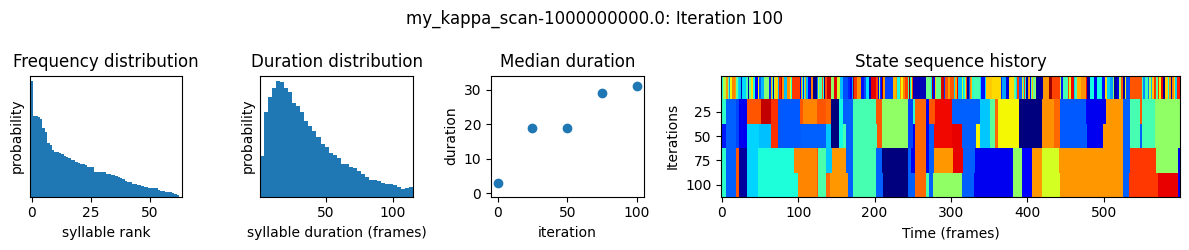

 50%|████████████████▉                 | 75/151 [04:56<05:01,  3.96s/it]

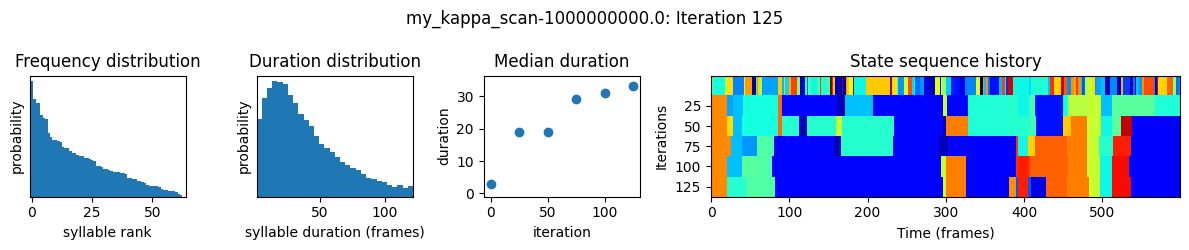

 66%|█████████████████████▊           | 100/151 [06:37<03:21,  3.96s/it]

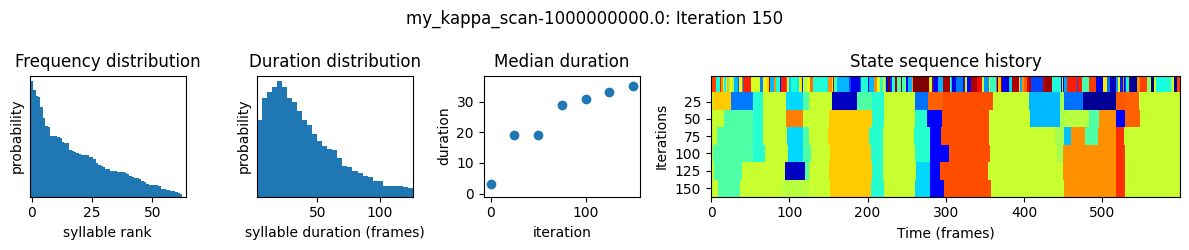

 83%|███████████████████████████▎     | 125/151 [08:18<01:43,  3.96s/it]

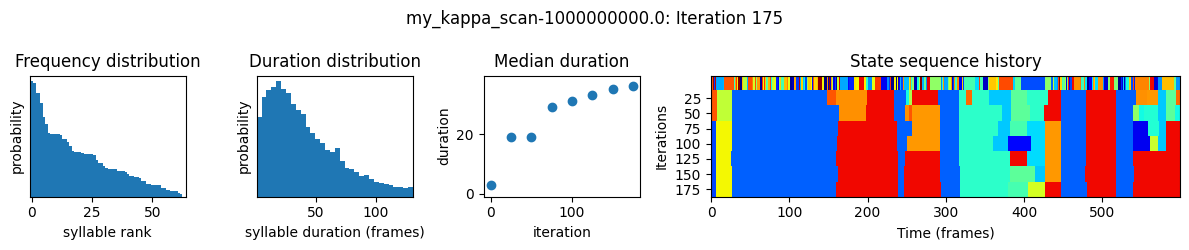

 99%|████████████████████████████████▊| 150/151 [09:59<00:03,  3.96s/it]

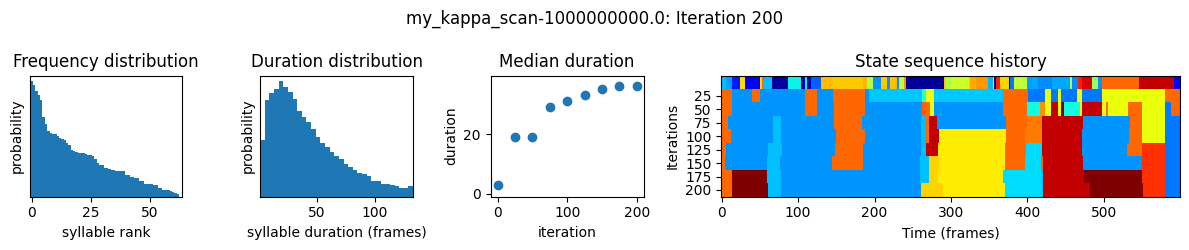

100%|█████████████████████████████████| 151/151 [10:05<00:00,  4.01s/it]


Fitting model with kappa=10000000000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-10000000000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.91s/it]

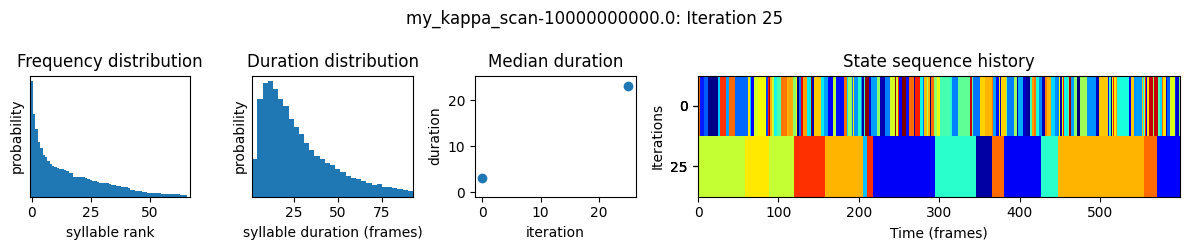

 98%|██████████████████████████████████▎| 50/51 [01:37<00:01,  1.91s/it]

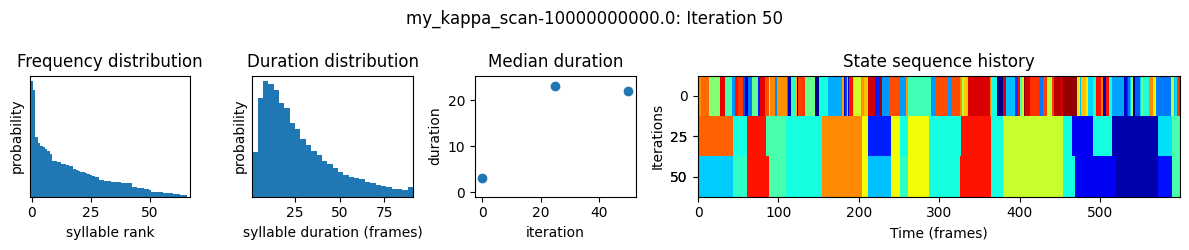

100%|███████████████████████████████████| 51/51 [01:41<00:00,  1.98s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-10000000000.0


 17%|█████▋                            | 25/151 [01:37<08:14,  3.92s/it]

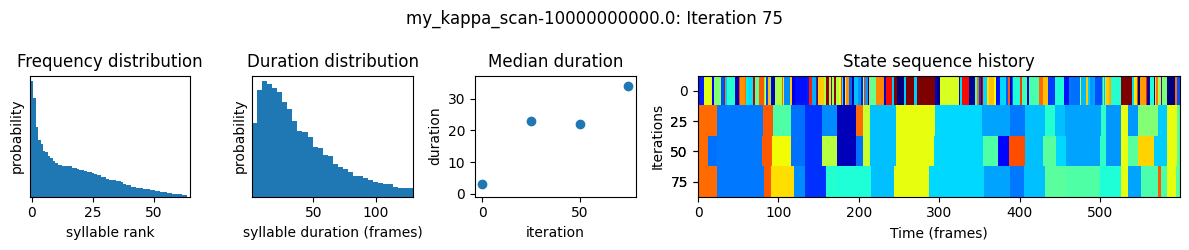

 33%|███████████▎                      | 50/151 [03:17<06:35,  3.91s/it]

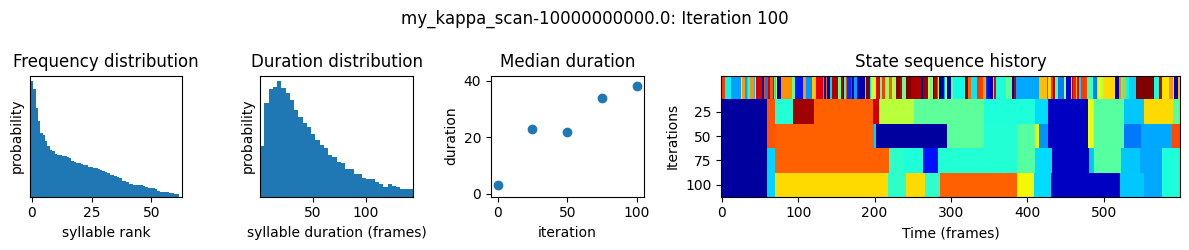

 50%|████████████████▉                 | 75/151 [04:56<04:57,  3.91s/it]

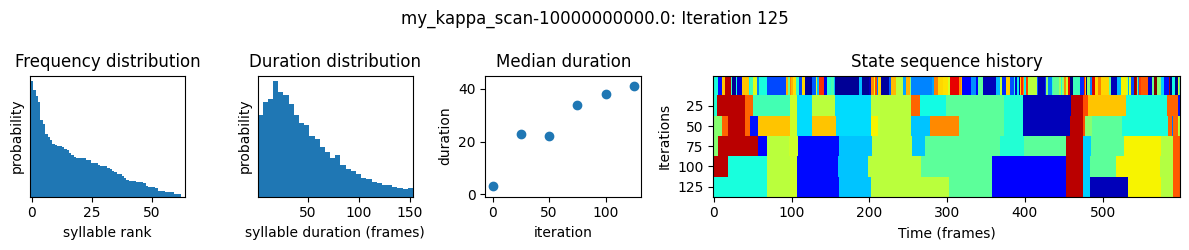

 66%|█████████████████████▊           | 100/151 [06:36<03:19,  3.92s/it]

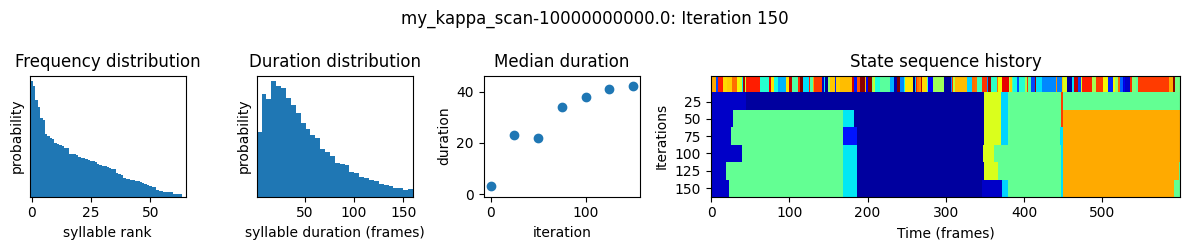

 83%|███████████████████████████▎     | 125/151 [08:16<01:41,  3.92s/it]

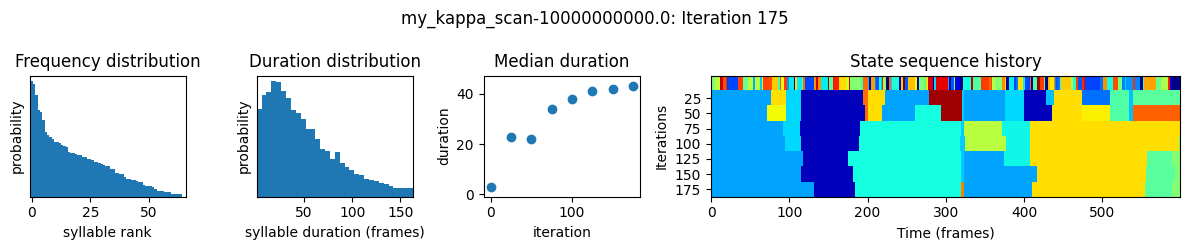

 99%|████████████████████████████████▊| 150/151 [09:55<00:03,  3.90s/it]

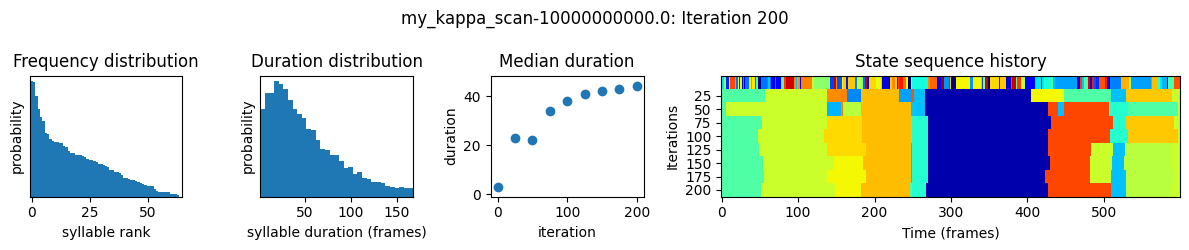

Loading checkpoints: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:03<00:00,  2.38it/s]


(<Figure size 800x250 with 2 Axes>,
 array([ 2.,  2.,  2.,  4.,  9., 20., 27., 36., 44.]))

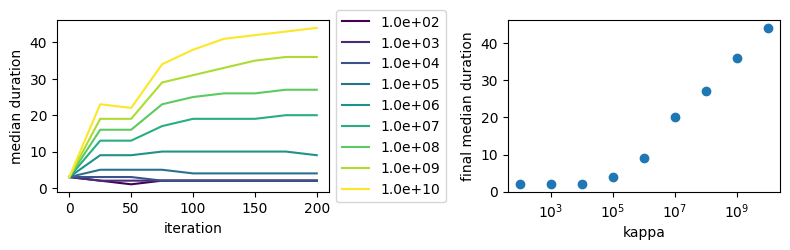

In [18]:
kappas = np.logspace(2,10,9)
decrease_kappa_factor = 10
num_ar_iters = 50
num_full_iters = 200

prefix = 'my_kappa_scan'

for kappa in kappas:
    print(f"Fitting model with kappa={kappa}")
    model_name = f'{prefix}-{kappa}'
    model = kpms.init_model(data, pca=pca, **config())

    # stage 1: fit the model with AR only
    model = kpms.update_hypparams(model, kappa=kappa)
    model = kpms.fit_model(
        model,
        data,
        metadata,
        kpmoseq_dir,
        model_name,
        ar_only=True,
        num_iters=num_ar_iters,
        parallel_message_passing=True,
        save_every_n_iters=25
    )[0];

    # stage 2: fit the full model
    model = kpms.update_hypparams(model, kappa=kappa/decrease_kappa_factor)
    kpms.fit_model(
        model,
        data,
        metadata,
        kpmoseq_dir,
        model_name,
        ar_only=False,
        start_iter=num_ar_iters,
        num_iters=num_full_iters,
        parallel_message_passing=True,
        save_every_n_iters=25
    );

kpms.plot_kappa_scan(kappas, kpmoseq_dir, prefix)

Models:  [Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-100.0'), Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-1000.0'), Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-10000.0'), Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-100000.0'), Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-1000000.0'), Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-10000000.0'), Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DL

100%|█████████████████████████████████████| 9/9 [01:54<00:00, 12.68s/it]


Best model: /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-10000.0


(<Figure size 400x350 with 1 Axes>, <Axes: ylabel='EML score'>)

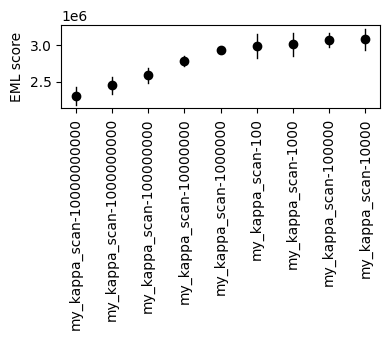

In [27]:
model_names = [f for f in Path(kpmoseq_dir).rglob(f"*{prefix}*")]
print("Models: ", model_names)

eml_scores, eml_std_errs = kpms.expected_marginal_likelihoods(kpmoseq_dir, model_names)
best_model = model_names[np.argmax(eml_scores)]
print(f"\nBest model: {best_model}")

kpms.plot_eml_scores(eml_scores, eml_std_errs, [str(Path(f).stem) for f in model_names])

## Train more iterations with best models

Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/fullModel_100000.0


  8%|██▊                               | 25/301 [01:42<18:46,  4.08s/it]

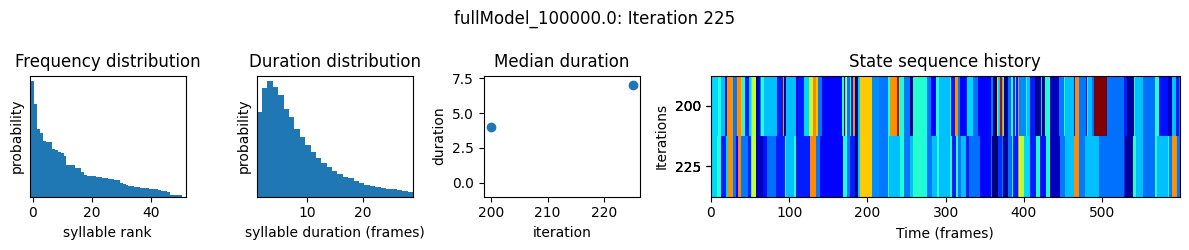

 17%|█████▋                            | 50/301 [03:26<17:07,  4.09s/it]

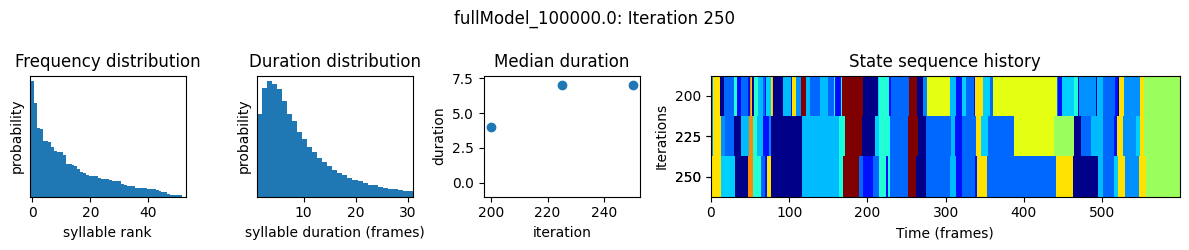

 25%|████████▍                         | 75/301 [05:08<15:09,  4.02s/it]

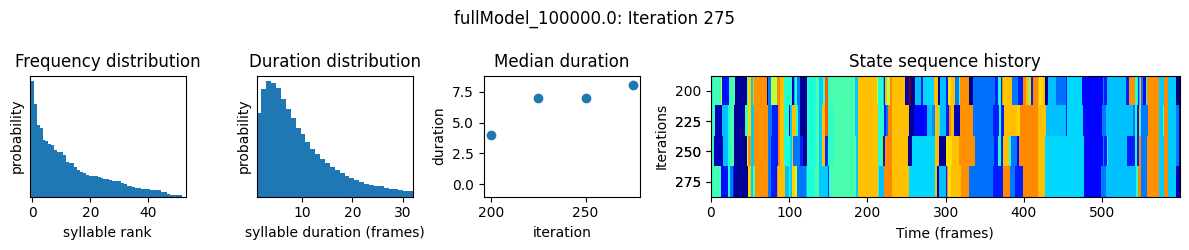

 33%|██████████▉                      | 100/301 [06:50<13:28,  4.02s/it]

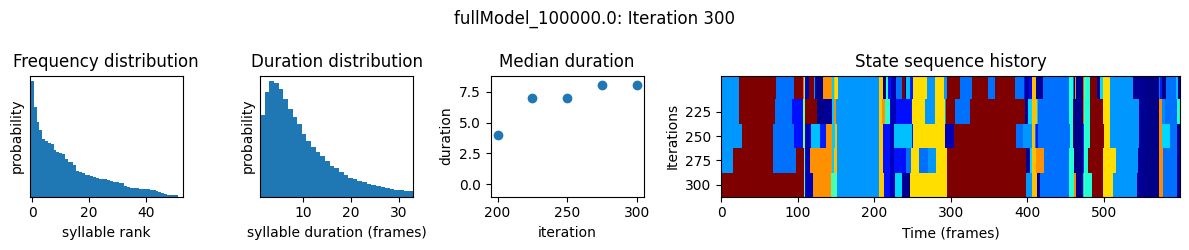

 42%|█████████████▋                   | 125/301 [08:32<11:48,  4.03s/it]

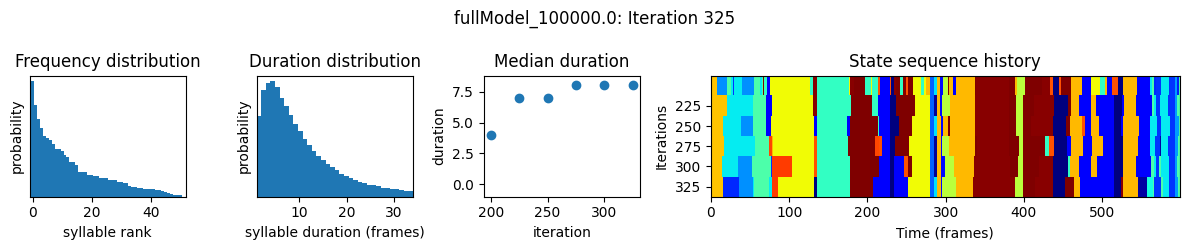

 50%|████████████████▍                | 150/301 [10:15<10:06,  4.02s/it]

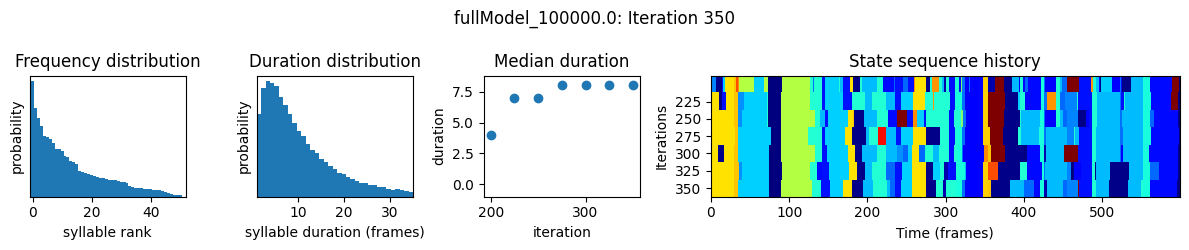

 58%|███████████████████▏             | 175/301 [11:57<08:26,  4.02s/it]

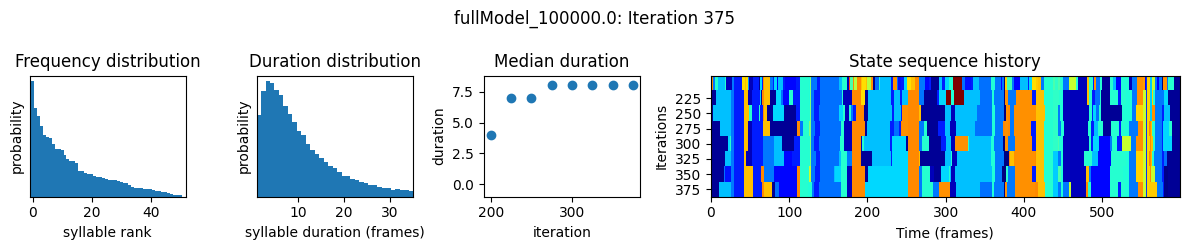

 66%|█████████████████████▉           | 200/301 [13:39<06:45,  4.02s/it]

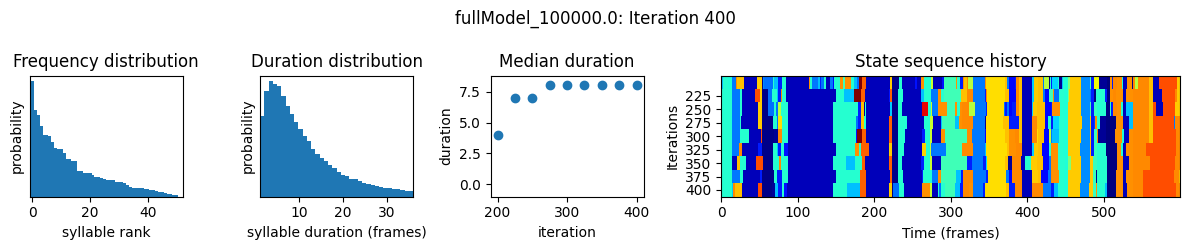

 75%|████████████████████████▋        | 225/301 [15:22<05:06,  4.03s/it]

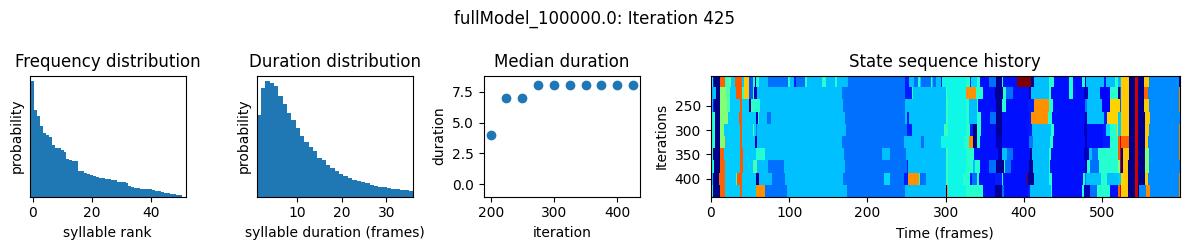

 83%|███████████████████████████▍     | 250/301 [17:06<03:28,  4.09s/it]

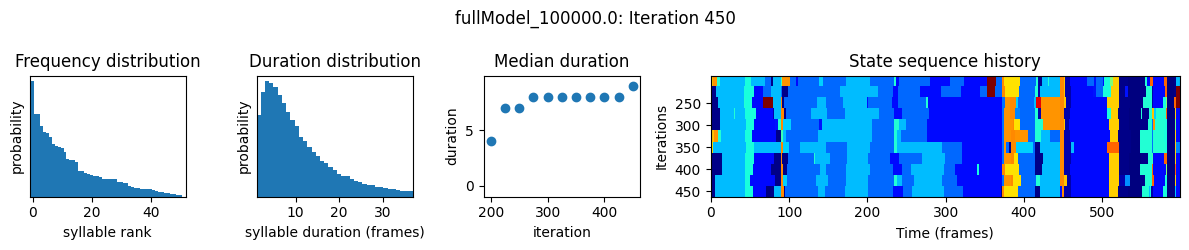

 91%|██████████████████████████████▏  | 275/301 [18:50<01:46,  4.08s/it]

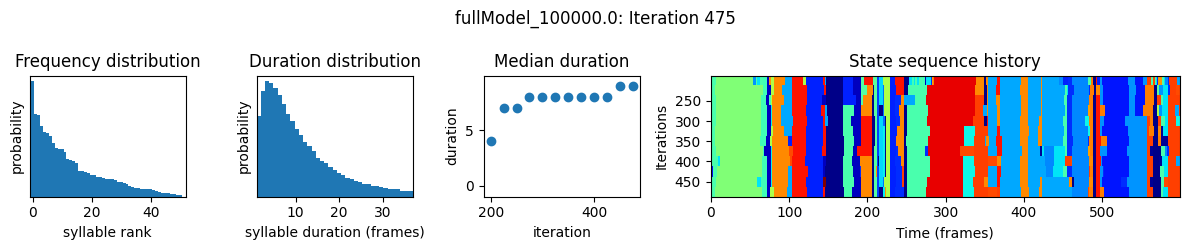

100%|████████████████████████████████▉| 300/301 [20:35<00:04,  4.08s/it]

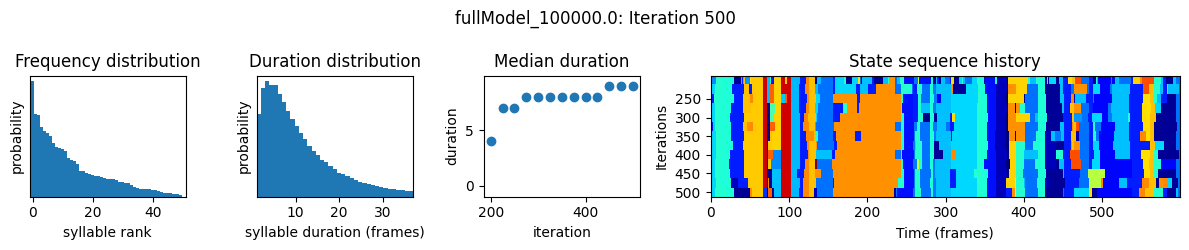

100%|█████████████████████████████████| 301/301 [20:41<00:00,  4.12s/it]


In [33]:
kappa = 1.0e5
model_name = "my_kappa_scan-100000.0"

model_to_fit, data, metadata, current_iter = kpms.load_checkpoint(
    kpmoseq_dir, model_name
)

# modify kappa to maintain the desired syllable time-scale
model_to_fit = kpms.update_hypparams(model_to_fit, kappa = kappa)


# run fitting for an additional 300 iters
model = kpms.fit_model(
    model_to_fit,
    data,
    metadata,
    kpmoseq_dir,
    f"fullModel_{kappa}",
    ar_only=False,
    start_iter=current_iter,
    num_iters=current_iter + 300,
)[0]

## Generating results

In [ ]:
kappa = 1e4
model_name = f"fullModel_{kappa}"

model, data, metadata, current_iter = kpms.load_checkpoint(kpmoseq_dir,
                                                           model_name)
model = kpms.update_hypparams(model, kappa=kappa)

In [11]:
# extract results
results = kpms.extract_results(model, 
                               metadata, 
                               kpmoseq_dir, 
                               model_name)

Saved results to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/fullModel_100000.0/results.h5


Saving trajectory plots to /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/fullModel_100000.0/trajectory_plots


Generating trajectory plots: 100%|██████| 41/41 [00:23<00:00,  1.75it/s]


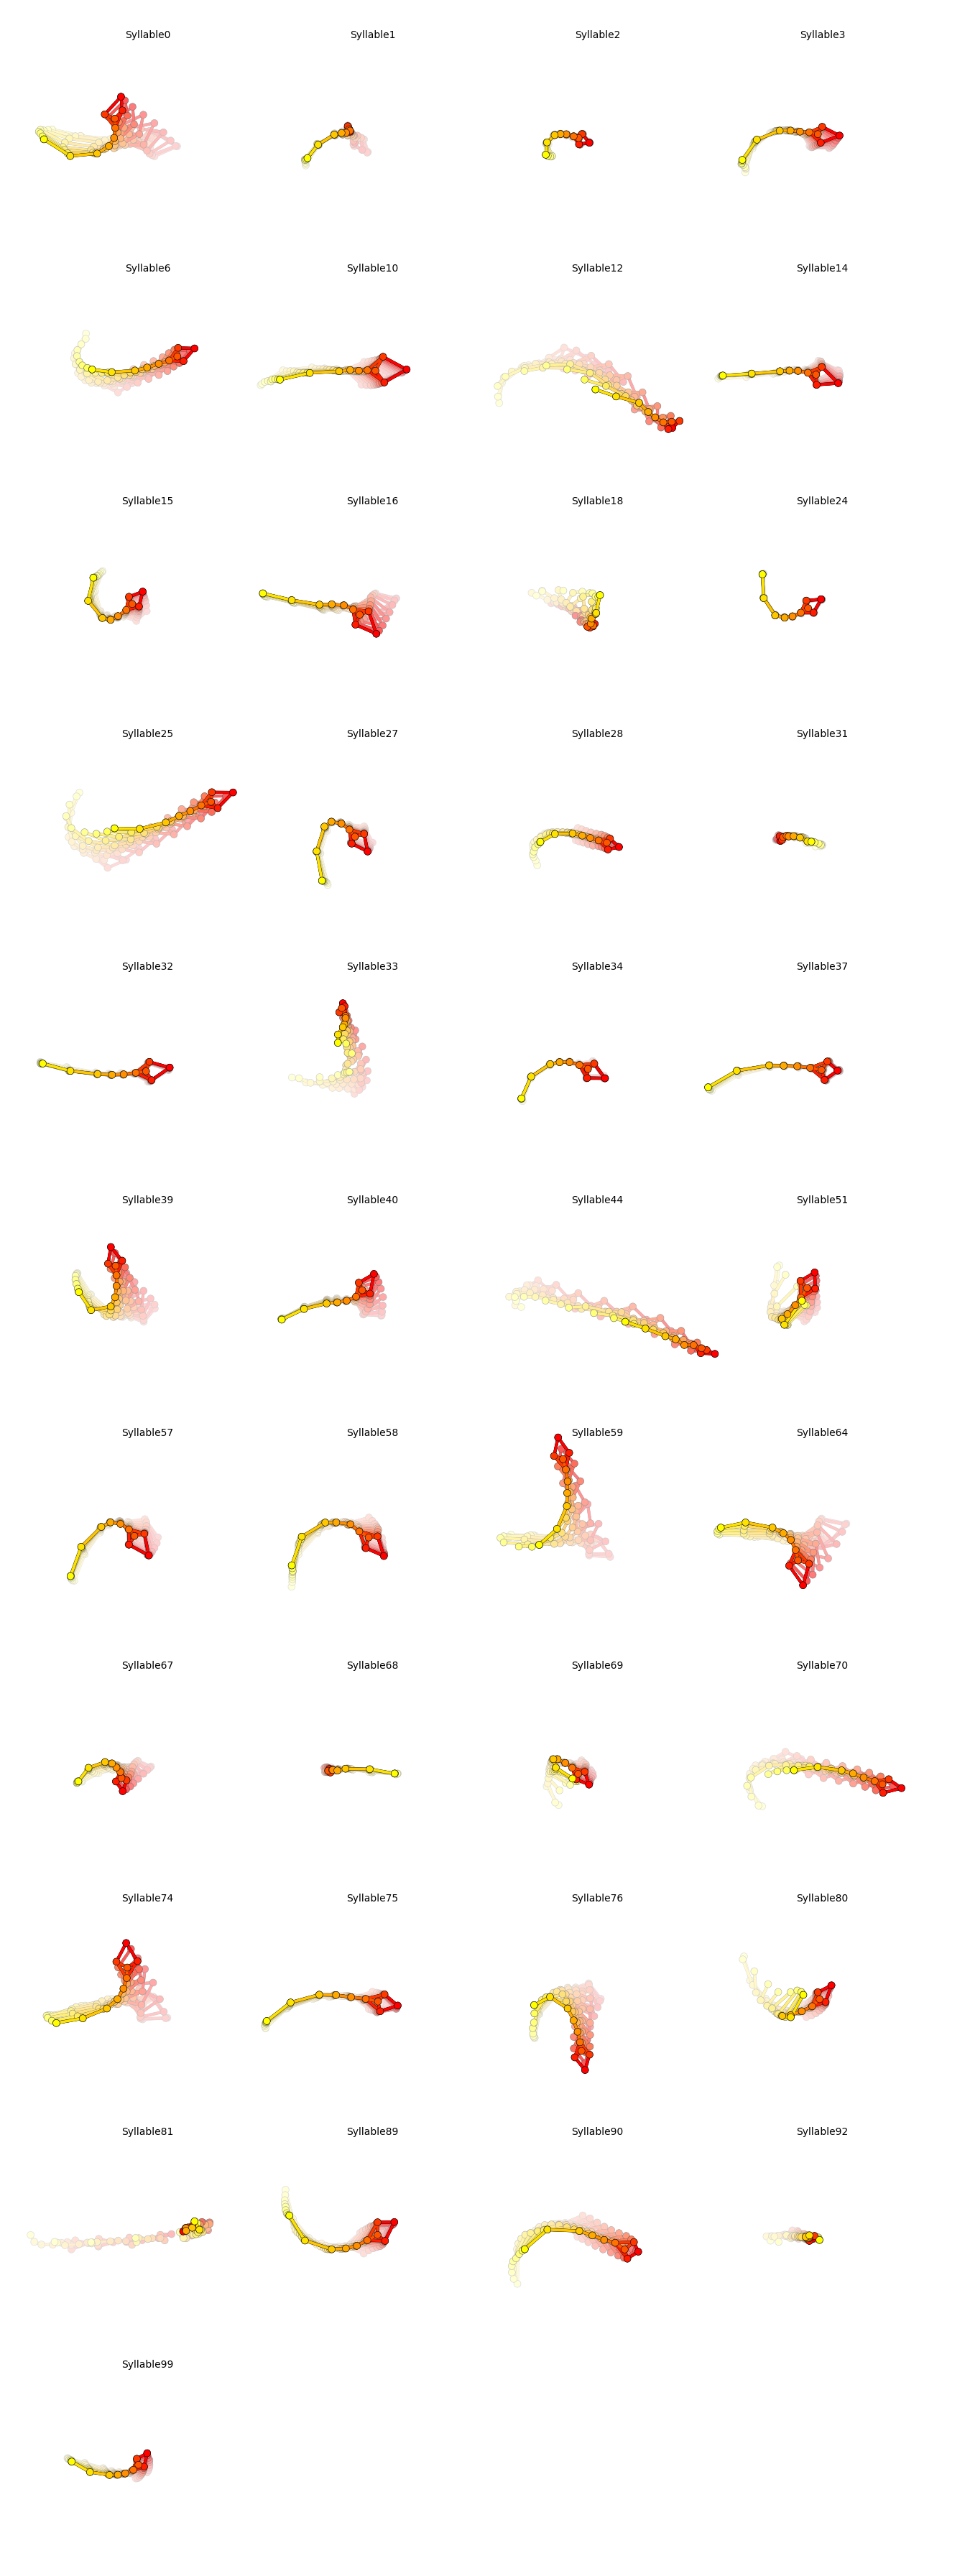

In [12]:
results = kpms.load_results(kpmoseq_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, kpmoseq_dir, model_name, **config())

In [13]:
kpms.generate_grid_movies(results, kpmoseq_dir, model_name, coordinates=coordinates, **config(), overlay_keypoints=True);


Writing grid movies to /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/fullModel_100000.0/grid_movies
Using window size of 288 pixels


Generating grid movies: 100%|███████████| 41/41 [02:02<00:00,  2.99s/it]os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


In [ ]:

kpms.plot_similarity_dendrogram(coordinates, results, kpmoseq_dir, model_name, **config())

In [7]:
h5Dataset = Path("/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/analyzedVideos_unifiedDataset_DLC_singleAnimal_downsampled_10fps")

allData = [str(f) for f in h5Dataset.rglob("*.h5")]
allData

['/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/analyzedVideos_unifiedDataset_DLC_singleAnimal_downsampled_10fps/mouse1010819/topView_DLCtracking_pcutoff_0.8_skeleton/mouse1010819_Day02_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk.h5',
 '/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/analyzedVideos_unifiedDataset_DLC_singleAnimal_downsampled_10fps/mouse1010819/topView_DLCtracking_pcutoff_0.8_skeleton/mouse1010819_Day04_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk.h5',
 '/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/analyzedVideos_unifiedDataset_DLC_singleAnimal_downsampled_10fps/mouse1010819/topView_DLCtracking_pcutoff_0.8_skeleton/mouse1010819_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk.h5',
 '/p

In [8]:
from collections import defaultdict

paths = [
    # your path strings here
]

pattern = re.compile(r"(mouse\d+)_Day0*(\d+)", re.IGNORECASE)

grouped = defaultdict(list)

for path in paths:
    filename = Path(path).name
    match = pattern.search(filename)

    if match:
        mouse_id = match.group(1).lower()
        day_id = int(match.group(2))

        key = (mouse_id, day_id)
        grouped[key].append(path)
    else:
        print(f"Could not extract mouse/day from: {path}")

duplicates = {
    key: matching_paths
    for key, matching_paths in grouped.items()
    if len(matching_paths) > 1
}

if duplicates:
    print("Possible duplicate mouse/day combinations:\n")

    for (mouse_id, day_id), matching_paths in sorted(duplicates.items()):
        print(f"{mouse_id}_Day{day_id:02d} — {len(matching_paths)} files")

        for path in matching_paths:
            print(f"  {Path(path).name}")

        print()
else:
    print("No duplicate mouse/day combinations found.")

No duplicate mouse/day combinations found.


In [31]:
def extract_id(k):
    name = Path(k).name
    m = re.search(r"(mouse\d+).*?(Day\d+)", name, re.IGNORECASE)
    if not m:
        return None
    part = re.search(r"(pt\d+)", name, re.IGNORECASE)
    return f"{m.group(1).lower()}_{m.group(2)}" + (f"_{part.group(1).lower()}" if part else "")

def clean_keys(d):
    new_d = {}
    for k, v in d.items():
        new_key = extract_id(k)
        if new_key is None:
            continue  # or raise error if you prefer
        new_d[new_key] = v
    return new_d

In [32]:
coordinates, confidences, bodyparts = kpms.load_keypoints(allData, 
                                                          "deeplabcut", 
                                                          path_in_name=True)

coordinates = clean_keys(coordinates)
confidences = clean_keys(confidences)

Loading keypoints: 100%|██████████████| 850/850 [00:26<00:00, 31.66it/s]


In [33]:
# Checking for file collisions
groups, nones = defaultdict(list), []
for f in allData:                       # the raw 850
    kid = extract_id(f)
    (nones if kid is None else groups[kid]).append(f)

print("files:", len(allData), "| None:", len(nones), "| unique ids:", len(groups))
for key, members in groups.items():
    if len(members) > 1:
        print(key)
        for m in members:
            print("   ", Path(m).name)

files: 850 | None: 0 | unique ids: 850


In [34]:
coordinates, confidences = kpms.outlier_removal(coordinates,
                                                confidences,
                                                kpmoseq_dir,
                                                overwrite=True,
                                                **config())

data, metadata = kpms.format_data(coordinates, 
                                  confidences, 
                                  **config())

In [35]:
import pickle
import jax
import numpy as np

# Move all JAX arrays from GPU to CPU before saving
checkpoint = {
    "data": jax.tree.map(
        lambda x: np.asarray(jax.device_get(x)) if hasattr(x, "shape") else x,
        data
    ),
    "metadata": metadata,
}

with open("/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/formattedData_forInference.pkl", "wb") as f:
    pickle.dump(checkpoint, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved data and metadata to formatted_data.pkl")

Saved data and metadata to formatted_data.pkl


In [4]:
import pickle
import jax

with open("formatted_data.pkl", "rb") as f:
    checkpoint = pickle.load(f)

data = jax.tree.map(
    lambda x: jax.device_put(x) if hasattr(x, "shape") else x,
    checkpoint["data"]
)

metadata = checkpoint["metadata"]

print("Loaded data and metadata")

Loaded data and metadata


In [40]:
from jax_moseq.utils import set_mixed_map_iters, set_mixed_map_gpus, get_mixed_map_gpus, get_mixed_map_iters

#set_mixed_map_gpus(2)
set_mixed_map_iters(8)  # process the mapped workload in one serial step

print("JAX backend:", jax.default_backend())
print("Visible JAX devices:", jax.device_count())
print("Local JAX devices:", jax.local_device_count())
print("mixed_map GPUs:", get_mixed_map_gpus())
print("mixed_map serial iterations:", get_mixed_map_iters())

for device in jax.devices():
    print(device)

kappa = 1e4
model_name = f"fullModel_{kappa}"

model, prevData, prevMetadata, current_iter = kpms.load_checkpoint(kpmoseq_dir,
                                                           model_name)

JAX backend: gpu
Visible JAX devices: 2
Local JAX devices: 2
mixed_map GPUs: 1
mixed_map serial iterations: 8
cuda:0
cuda:1


In [ ]:
results = kpms.apply_model(model, 
                           data, 
                           metadata, 
                           kpmoseq_dir,
                           model_name=model_name,
                           overwrite = True,
                           parallel_message_passing=True,
                           **config())

Applying model:  26%|███▉           | 131/500 [32:29<1:31:30, 14.88s/it]

In [38]:
len(results.keys())

850

In [15]:
results = kpms.load_results(kpmoseq_dir, model_name)

Saving trajectory plots to /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/fullModel_100000.0/trajectory_plots


Generating trajectory plots: 100%|██████| 40/40 [00:22<00:00,  1.75it/s]


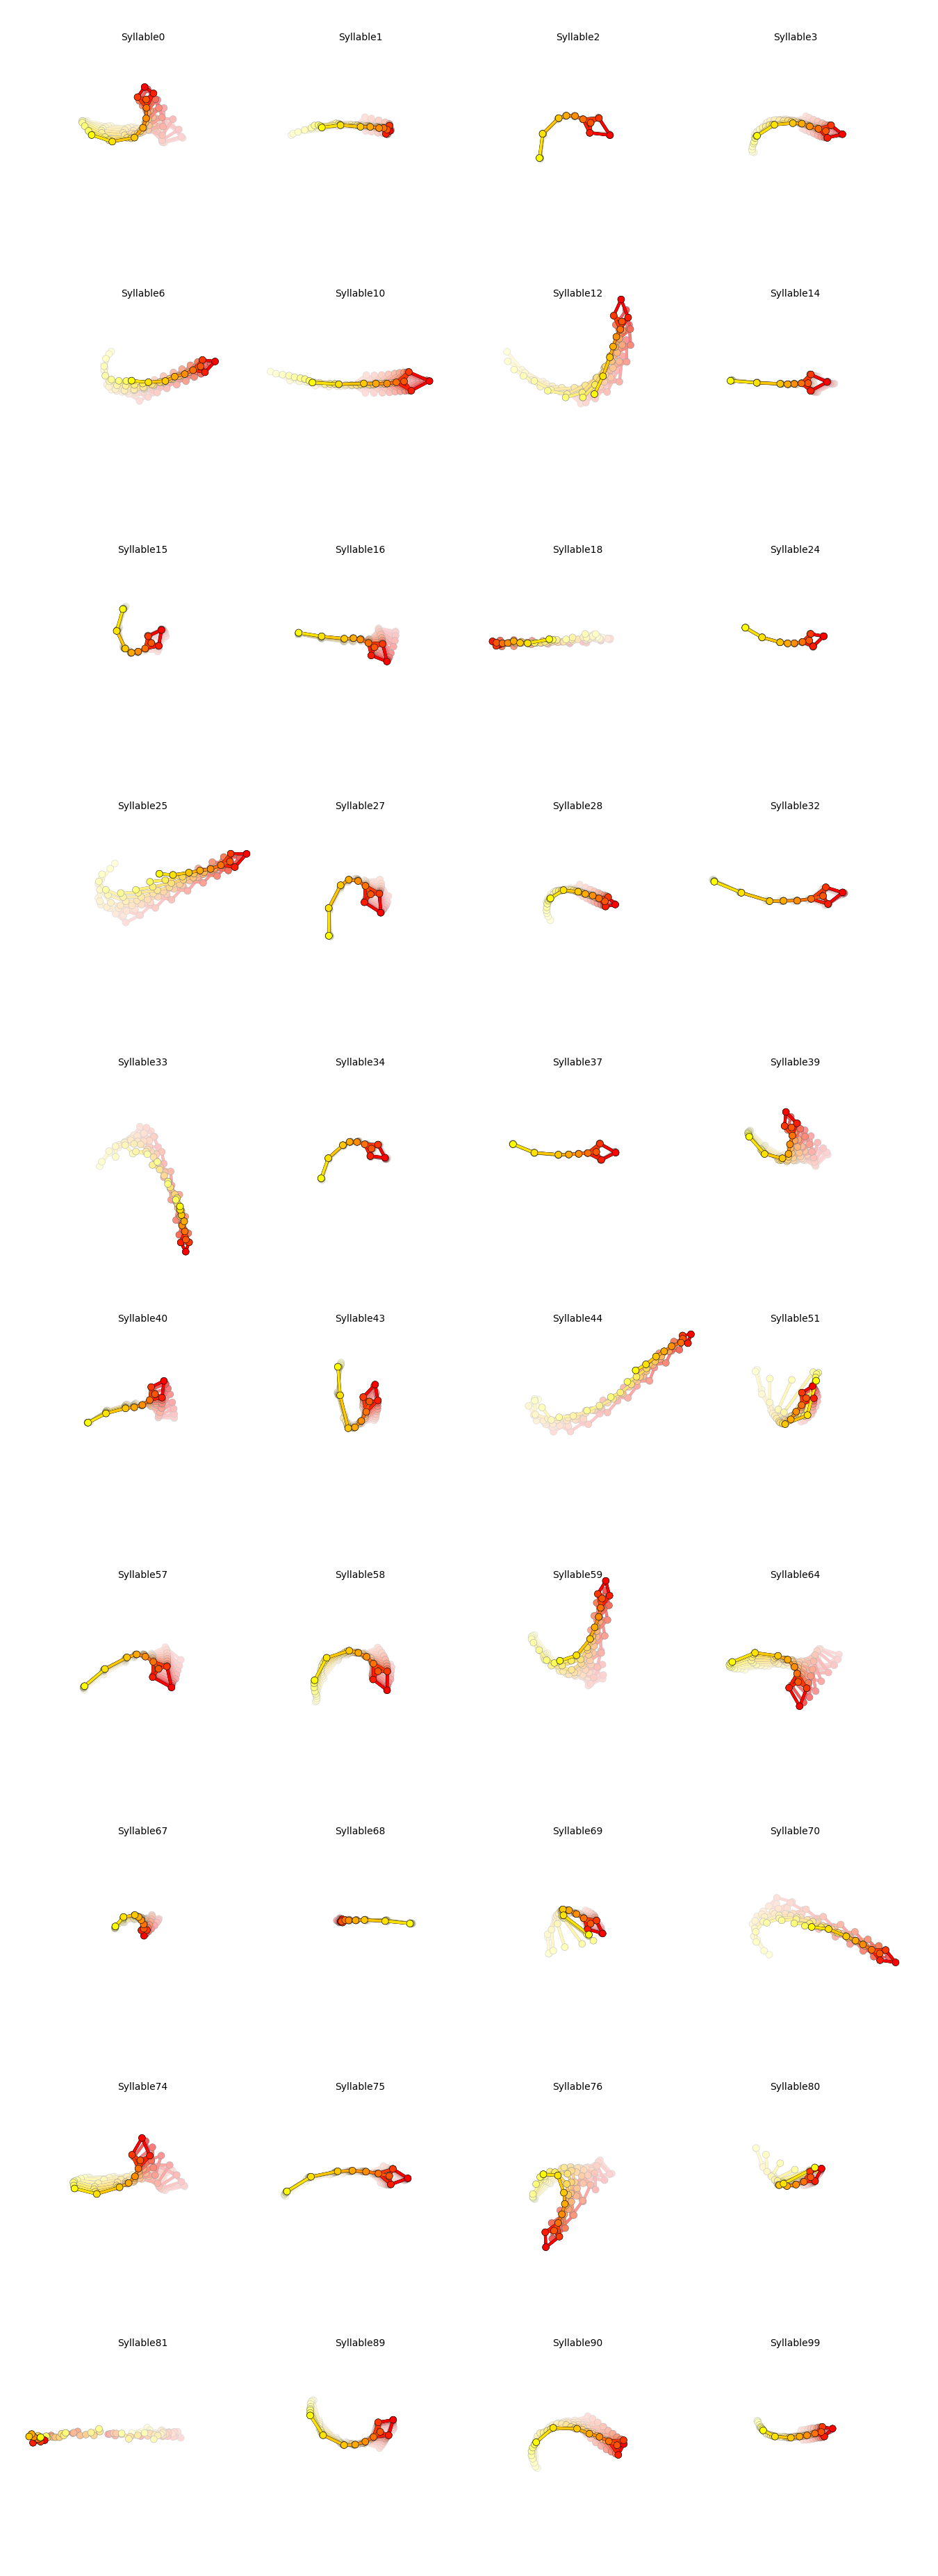

In [39]:
results = kpms.load_results(kpmoseq_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, kpmoseq_dir, model_name, **config())

# Results

In [112]:
# MR dataset
Agg = ["975826", "975827", "975833", "978772", "978774", "988590", "997838", "1010820", "1010823", "1010826", "1029741"]
nonAgg = ["975830", "978775", "1010819", "997839", "997840", "997841", "1029736", "1029739", "1032216"]
maladaptive = ["978513", "978527", "978528", "1010832", "1013590", "1034805", "1034814"]

saline_mice = ["978513", "978527", "978528"]
psilo_mice = ["1010832", "1013590", "1034805", "1034814"]

# Maladaptive prescreening dataset
extraMal = ["1034810", "1034811", "1034813","1034805", "1034807", "1034814",                                      # 20251215_16males_MR
            "1070005", "1070011", "1070015", "1070014",                                                           # 20260427_16males_AH&MR
            "1069997", "1069998",                                                                                 # 20260525_6males_AH
            "1075471", "1075472", "1075473", "1055495", "1079921", "1075521", "1075522"                           # 20260615_16males_AH
            "1079907", "1079925", "1087823", "1106648", "1106649"                                                 # 20260706_12males_AH
            ]                                                

extraAgg = ["1034819", "1034820", "1034821", "1034822", "1034823", "1034804", "1034806", "1034815", "1034818",    # 20251215_16males_MR
            "1070001", "1070002", "1070004", "1070006", "1070007", "1070008", "1070000", "1070012", "1070013",    # 20260427_16males_AH&MR
            "1069999", "1070008", "1070013",                                                                      # 20260525_6males_AH
            "1075470", "1055494", "1060703", "1079918", "1080864", "1079920", "1079922", "1075520", "1075523"     # 20260615_16males_AH
            "1079906", "1079908", "1087821", "1087822", "1087824", "1106647"                                      # 20260706_12males_AH
            ] 

extraNonAgg =["1034812",                                                                                          # 20251215_16males_MR
              "1070003", "1070009", "1070010",                                                                    # 20260427_16males_AH&MR
              "1069996",                                                                                          # 20260525_6males_AH
              "1087825"                                                                                           # 20260706_12males_AH
              ]


# Stefanos dataset
Agg_Ste = ["5281", "5282", "5111", "5112", "4901", "4902",                                                        # 20160630_ri2ndConditioning_males
           "5671", "5672", "5761", "5762", "5763", "5811",                                                        # 20160824_12males V1
           "5812", "5813", "5801", "5802", "5803", "5804",                                                        # 20160824_12males V2
           "486", "2302", "2304",                                                                                 # 20190510_6males
           "2323", "2324", "2326", "2327", "2330",                                                                # 20190529_12males V1
           "223", "225", "227", "243", "248", "2332",                                                             # 20190529_12males V2
           "2341", "2338", "237", "218", "219", "477",                                                            # 20190605_6males
           "2", "3", "4", "7", "9",                                                                               # 20190805_60males V1
           " 12", "13", "14", "17", "18", "19",                                                                   # 20190805_60males V2
           "22", "23", "24", "27", "28",                                                                          # 20190805_60males V3              
           "32", "33" "34", "37", "38", "39",                                                                     # 20190805_60males V4
           "42", "43", "44", "47", "48", "49",                                                                    # 20190805_60males V5
           "52", "53", "54", "57", "58", "59",                                                                    # 20190805_60males V1
]

nonAgg_Ste = ["484", "485",                                                                                       # 20190510_6males
              "8",                                                                                                # 20190805_60males V1
              "29",                                                                                               # 20190805_60males V3
              ]

maladaptive_Ste = ["2303",                                                                                        # 20190510_6males
                   "2325",                                                                                        # 20190529_12males V1
                   ]

# Stefanos dataset: Videos that were not segmented due low visibility
extraAgg_Ste = ["5", "6", "10", "11", "15", "21", "25", "26", "30", "31", "35", "36", "40", "41", "45", "46", "51", "56", "60"]
extraNonAgg_Ste = ["1", "16","20", "50", "55"]


Agg = Agg + extraAgg + Agg_Ste + extraAgg_Ste + maladaptive + maladaptive_Ste + extraMal
nonAgg = nonAgg + extraNonAgg + nonAgg_Ste + extraNonAgg_Ste
#maladaptive = maladaptive + maladaptive_Ste + extraMal
maladaptive = []

kappa = 1e4
model_name = f"fullModel_{kappa}"

results = kpms.load_results(kpmoseq_dir, model_name)

In [113]:
rows = []
skipped = []

saline_mice = maladaptive[:3]
psilo_mice = maladaptive[3:]   # non-overlapping

for video in results.keys():

    m = re.match(r"mouse(\d+)_Day(\d+)", video)

    if m is None:
        skipped.append({"recording": video, "reason": "regex_no_match"})
        continue

    mouse = m.group(1)
    day = int(m.group(2))

    if mouse in Agg:
            group = "Agg"

    elif mouse in nonAgg:
            group = "nonAgg"

    elif mouse in maladaptive and day <= 5:
        group = "maladaptive baseline"

    elif mouse in psilo_mice and day >= 15:
        group = "maladaptive Psilocybin"

    elif mouse in saline_mice and day >= 15:
        group = "maladaptive Saline"

    else:
        skipped.append({
            "recording": video,
            "mouse": mouse,
            "day": day,
            "reason": "mouse_not_in_group_lists"
        })
        continue

    mouse_group_id = f"{mouse}_{group}"

    rows.append({
        "video": video,
        "mouse": mouse,                 # original animal ID
        "mouse_group_id": mouse_group_id, # analysis ID
        "day": day,
        "group": group
    })

resultsDataset = pd.DataFrame(rows)
skipped_df = pd.DataFrame(skipped)

In [114]:
all_syllables = np.concatenate([np.asarray(results[r]["syllable"]) for r in results])
n_syll = int(all_syllables.max()) + 1          # index-safe: labels are 0..n_syll-1

def transition_probs(seq, n_syll):
    M = np.zeros((n_syll, n_syll))
    seq = np.asarray(seq)
    if len(seq) > 1:
        np.add.at(M, (seq[:-1], seq[1:]), 1)
    row = M.sum(1, keepdims=True)
    return np.divide(M, row, where=row > 0, out=np.zeros_like(M))

rows = []
for rec in results:
    s = np.asarray(results[rec]["syllable"])
    row = {"video": rec}

    # syllable usage = fraction of time (NO extra /n_samples)
    counts = np.bincount(s, minlength=n_syll)[:n_syll]
    total = counts.sum()
    freq = counts / total if total > 0 else np.zeros(n_syll)
    for i, f in enumerate(freq):
        row[f"syll_{i}"] = f

    # transition probabilities P(next=j | current=i)
    P = transition_probs(s, n_syll)
    for i in range(n_syll):
        for j in range(n_syll):
            row[f"trans_{i}_{j}"] = P[i, j]

    rows.append(row)

usage = pd.DataFrame(rows).fillna(0)
df = resultsDataset.merge(usage, on="video", how="inner")

In [115]:
mouse_df = (
    df.groupby(["mouse_group_id", "group"])
    .mean(numeric_only=True)
    .reset_index()
)

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import KFold


# -----------------------------
# settings
# -----------------------------
group_colors = {
    "nonAgg": "#5AA2E6",
    "Agg": "#E6A55A",
    "maladaptive": "#E65A5A"
}

group_markers = {
    "nonAgg": "o",
    "Agg": "s",
    "maladaptive": "^"
}

group_order = [
    "nonAgg",
    "Agg",
    "maladaptive"
]

pc_cmap = LinearSegmentedColormap.from_list(
    "blue_orange_red",
    ["#5AA2E6", "#E6A55A", "#E65A5A"]
)


# -----------------------------
# prepare data
# IMPORTANT:
# use video-level df, not mouse_df
# -----------------------------
plot_df = df.copy()

plot_df["group"] = plot_df["group"].astype(str).str.strip()
plot_df["day"] = pd.to_numeric(plot_df["day"], errors="coerce")


# -----------------------------
# remove psilocybin post-treatment videos
# -----------------------------
plot_df = plot_df[
    ~plot_df["group"].isin([
        "maladaptive Psilocybin",
        "maladaptive after Psilocybin"
    ])
].copy()


# -----------------------------
# merge groups for plotting / analysis
# -----------------------------
plot_df["group_plot"] = plot_df["group"].replace({
    "naive Agg": "Agg",
    "naive nonAgg": "nonAgg",

    "maladaptive baseline": "maladaptive",
    "maladaptive Saline": "maladaptive",
    "maladaptive after Saline": "maladaptive"
})


# -----------------------------
# keep groups of interest
# -----------------------------
plot_df = plot_df[
    plot_df["group_plot"].isin(group_order)
].copy()


print("Video-level groups before mouse averaging:")
print(plot_df["group"].value_counts())

print("\nMerged video-level groups before mouse averaging:")
print(plot_df["group_plot"].value_counts())

print("\nVideos per mouse/group before averaging:")
print(
    plot_df
    .groupby(["mouse", "group", "group_plot"])
    .size()
    .reset_index(name="n_videos")
    .sort_values(["group_plot", "mouse", "group"])
)


# -----------------------------
# collapse all videos/days to one row per mouse
# baseline + saline from same mouse become one maladaptive point
# -----------------------------
plot_df = (
    plot_df
    .groupby(["mouse", "group_plot"], as_index=False)
    .mean(numeric_only=True)
)


group_order_present = [
    g for g in group_order
    if g in plot_df["group_plot"].unique()
]

print("\nGroups included after mouse averaging:")
print(plot_df["group_plot"].value_counts())

print("\nMouse/group rows after averaging:")
print(
    plot_df[["mouse", "group_plot"]]
    .sort_values(["group_plot", "mouse"])
)


# -----------------------------
# features
# -----------------------------
X_df = plot_df.filter(regex="^(syll|trans)_").copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

min_recordings = 1
presence = (X_df > 0.01).sum(axis=0)          # "meaningfully present", not just >0
valid_features = presence[presence >= 3].index
X_df = X_df[valid_features]

X_log = np.log(X_df + 1e-8)


# -----------------------------
# mutual information
# -----------------------------
y = LabelEncoder().fit_transform(plot_df["group_plot"])

X_scaled = StandardScaler().fit_transform(X_log)

mi = mutual_info_classif(
    X_scaled,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi,
    index=X_df.columns
).sort_values(ascending=False)

top_n = int(len(valid_features) /5)
top_features = mi_scores.head(top_n).index

print("\nTop MI features:")
print(mi_scores.head(top_n))


# -----------------------------
# cvPCA
# -----------------------------
X_selected = X_log[top_features]
X_selected_scaled = StandardScaler().fit_transform(X_selected)

n_components = 2
n_splits = min(5, X_selected_scaled.shape[0])

kf = KFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

cv_explained = np.zeros(n_components)
cv_total_var = 0.0

for train_idx, test_idx in kf.split(X_selected_scaled):

    X_train = X_selected_scaled[train_idx]
    X_test = X_selected_scaled[test_idx]

    # fit PCA only on training mice
    pca_fold = PCA(n_components=n_components)
    pca_fold.fit(X_train)

    # project held-out mice onto train PCs
    X_test_scores = pca_fold.transform(X_test)

    # total held-out variance
    cv_total_var += np.sum(X_test ** 2)

    # cross-validated variance explained by each PC
    for pc in range(n_components):
        scores_pc = X_test_scores[:, [pc]]
        components_pc = pca_fold.components_[[pc], :]
        recon_pc = scores_pc @ components_pc

        cv_explained[pc] += np.sum(recon_pc ** 2)

cv_explained_variance_ratio = cv_explained / cv_total_var


# -----------------------------
# final PCA fit for coordinates/loadings
# -----------------------------
# cvPCA estimates held-out explained variance.
# The plotted PC coordinates/loadings are from PCA fit on all mice.
pca = PCA(n_components=n_components)
Y = pca.fit_transform(X_selected_scaled)

plot_df["PC1"] = Y[:, 0]
plot_df["PC2"] = Y[:, 1]

# store cvPCA variance on the PCA object for plotting labels
pca.cv_explained_variance_ratio_ = cv_explained_variance_ratio

print("\nCross-validated explained variance:")
print(f"cvPC1: {pca.cv_explained_variance_ratio_[0] * 100:.1f}%")
print(f"cvPC2: {pca.cv_explained_variance_ratio_[1] * 100:.1f}%")
print(f"Total cvPC1 + cvPC2: {pca.cv_explained_variance_ratio_[:2].sum() * 100:.1f}%")

print("\nRegular PCA explained variance, for comparison:")
print(f"PC1: {pca.explained_variance_ratio_[0] * 100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1] * 100:.1f}%")


# -----------------------------
# PC1 loadings
# -----------------------------
pc1_weights = pd.Series(
    pca.components_[0],
    index=top_features,
    name="PC1_weight"
)

top_loadings = (
    pc1_weights
    .reindex(pc1_weights.abs().sort_values(ascending=False).head(20).index)
    .sort_values()
)


# -----------------------------
# PC1 distribution data
# -----------------------------
violin_data = [
    plot_df.loc[plot_df["group_plot"] == g, "PC1"].values
    for g in group_order_present
]


# -----------------------------
# per-group syllable contribution to PC1
# -----------------------------
X_selected_df = pd.DataFrame(
    X_selected_scaled,
    columns=top_features,
    index=plot_df.index
)

pc1_contrib = X_selected_df.mul(pc1_weights, axis=1)
pc1_contrib["group"] = plot_df["group_plot"].values

group_pc1_contrib = (
    pc1_contrib
    .groupby("group")
    .mean()
    .T
)

top_heat_n = top_n

top_syllables = (
    group_pc1_contrib.abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .head(top_heat_n)
    .index
)

heat = group_pc1_contrib.loc[top_syllables, group_order_present]


# -----------------------------
# same color range for loading barplot and heatmap
# -----------------------------
max_abs = max(
    np.abs(top_loadings.values).max(),
    np.abs(heat.values).max()
)

norm = Normalize(vmin=-max_abs, vmax=max_abs)
sm = ScalarMappable(norm=norm, cmap=pc_cmap)
sm.set_array([])


# -----------------------------
# output
# -----------------------------
mouse_pca_df = plot_df.copy()

Video-level groups before mouse averaging:
group
Agg       691
nonAgg    121
Name: count, dtype: int64

Merged video-level groups before mouse averaging:
group_plot
Agg       691
nonAgg    121
Name: count, dtype: int64

Videos per mouse/group before averaging:
       mouse   group group_plot  n_videos
1    1010820     Agg        Agg        11
2    1010823     Agg        Agg        11
3    1010826     Agg        Agg        11
4    1010832     Agg        Agg         9
5    1013590     Agg        Agg         9
..       ...     ...        ...       ...
123   975830  nonAgg     nonAgg         9
130   978775  nonAgg     nonAgg         9
133   997839  nonAgg     nonAgg        10
134   997840  nonAgg     nonAgg        10
135   997841  nonAgg     nonAgg        10

[136 rows x 4 columns]

Groups included after mouse averaging:
group_plot
Agg       120
nonAgg     16
Name: count, dtype: int64

Mouse/group rows after averaging:
       mouse group_plot
1    1010820        Agg
2    1010823        Agg

In [117]:
# -----------------------------
# plotting
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    gridspec_kw={"width_ratios": [1.1, 1]}, dpi = 800
)

# -----------------------------
# choose the correct group column
# -----------------------------
if "group_plot" in plot_df.columns:
    group_col = "group_plot"
elif "group_merged" in plot_df.columns:
    group_col = "group_merged"
else:
    raise KeyError("Neither 'group_plot' nor 'group_merged' exists in plot_df.")

group_order_present = [
    g for g in group_order
    if g in plot_df[group_col].unique()
]

violin_data = [
    plot_df.loc[plot_df[group_col] == g, "PC1"].values
    for g in group_order_present
]

heat_plot = heat[group_order_present]

# -----------------------------
# 1. PCA cloud
# -----------------------------
# detect the mouse-id column once
mouse_col = next(
    (c for c in ["mouse", "mouse_group_id", "video", "video_path"] if c in plot_df.columns),
    None
)

ax = axes[0, 0]

for g in group_order_present:
    sub = plot_df[plot_df[group_col] == g]

    ax.scatter(
        sub["PC1"],
        sub["PC2"],
        label=g,
        color=group_colors[g],
        marker=group_markers[g],
        alpha=0.8,
        s=90
    )

    if mouse_col is not None:
        for _, row in sub.iterrows():
            ax.annotate(
                str(row[mouse_col]),
                (row["PC1"], row["PC2"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=6,
                alpha=0.75
            )

ax.legend(loc="upper left", fontsize=8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("MI-selected PCA cloud")


# -----------------------------
# 2. Top PC1 syllable weights
# -----------------------------
ax = axes[0, 1]

bar_colors = [pc_cmap(norm(v)) for v in top_loadings.values]

ax.barh(
    top_loadings.index,
    top_loadings.values,
    color=bar_colors
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("PC1 loading / weight")
ax.set_ylabel("Syllable")
ax.set_title("Top syllable weights for PC1")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("PC1 loading / weight")


# -----------------------------
# 3. PC1 violin plot by group
# -----------------------------
ax = axes[1, 0]

vp = ax.violinplot(
    violin_data,
    showmeans=True,
    showmedians=False
)

for body, g in zip(vp["bodies"], group_order_present):
    body.set_facecolor(group_colors[g])
    body.set_edgecolor("black")
    body.set_alpha(0.5)

for key in ["cmeans", "cbars", "cmins", "cmaxes"]:
    vp[key].set_color("black")

ax.set_xticks(np.arange(1, len(group_order_present) + 1))
ax.set_xticklabels(group_order_present, rotation=30, ha="right")
ax.set_ylabel("PC1 score")
ax.set_title("PC1 distribution by group")


# -----------------------------
# 4. Syllable contributions to PC1 by group
# -----------------------------
ax = axes[1, 1]

im = ax.imshow(
    
    heat_plot,
    aspect="auto",
    cmap=pc_cmap,
    norm=norm
)

ax.set_xticks(np.arange(len(heat_plot.columns)))
ax.set_xticklabels(heat_plot.columns, rotation=30, ha="right")

ax.set_yticks(np.arange(len(heat_plot.index)))
ax.set_yticklabels(heat_plot.index)

ax.set_title("Syllable contributions to PC1 by group")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Mean contribution to PC1")

plt.tight_layout()
plt.show()